In [111]:
import time
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.pipeline import Pipeline

from cvxopt import matrix, solvers
from itertools import combinations
from collections import Counter

# Suppress cvxopt output
solvers.options['show_progress'] = False

### Dataset Recap and Feature Set Selection

We are using our dataset from the previous assignment. It consists of 3,071 samples belonging to 5 classes (apple, banana, mandarin, onion, potato), with a balanced class distribution. A total of 354 features were extracted by combining three modalities:

- Image features (19)
- Text features (300)
- Categorical features (34) 
- Fused features (354)

We evaluated four feature sets in Assignment 1. While the fused feature set achieved the highest performance, it made the classification problem almost linearly separable. Hence, to be able to analyse support vectors meaningfully and to design a sensible outlier detection framework, we will be using only our image dataset in Assignment 2.

In [112]:
df_labels = pd.read_csv("labels.csv", index_col=0)
y_raw = df_labels.to_numpy().flatten()
le = LabelEncoder()
y = le.fit_transform(y_raw)
X = pd.read_csv("fused.csv", index_col=0).to_numpy() 
X_image = pd.read_csv("image.csv", index_col=0).to_numpy()
X_text = pd.read_csv("text.csv", index_col=0).to_numpy()
X_meta = pd.read_csv("meta.csv", index_col=0).to_numpy().astype(float)
X_fused = pd.read_csv("fused.csv", index_col=0).to_numpy()

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {le.classes_}")
print(f"Samples per class: {pd.Series(y_raw).value_counts().to_dict()}")

feature_sets = {
    "Image": X_image,
    "Text": X_text,
    "Categorical": X_meta,
    "Fused": X_fused
}

print(f"\nFeature dimensions:")
for name, X_feat in feature_sets.items():
    print(f"  {name}: {X_feat.shape[1]} features")

Dataset shape: (3071, 354)
Number of classes: 5
Classes: ['apple' 'banana' 'mandarin' 'onion' 'potato']
Samples per class: {'potato': 692, 'onion': 638, 'mandarin': 628, 'apple': 609, 'banana': 504}

Feature dimensions:
  Image: 19 features
  Text: 300 features
  Categorical: 34 features
  Fused: 354 features


In [113]:
# Use the best performing feature set for remaining tasks
X_best = feature_sets["Image"]
print(f"\nUsing 'Image' features for remaining tasks.")

# Preprocessing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (Fit on Train, Transform Test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


Using 'Image' features for remaining tasks.


We will use Image as it has an acceptable accuracy and also variance in cross validation

## TASK 1.1

TASK 1.1: Benchmarking Classifiers

CLASSIFIER BENCHMARK RESULTS
   Classifier                                                      Best Params  CV Accuracy  Test Accuracy  Training Time (s)
 SVM (Linear)                                                       {'C': 100}       0.7191         0.7122             2.3761
    SVM (RBF)                                         {'C': 100, 'gamma': 0.1}       0.8506         0.8520             0.1792
   SVM (Poly)                        {'C': 100, 'degree': 3, 'gamma': 'scale'}       0.8322         0.8244             0.2738
         k-NN {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}       0.7899         0.7886             0.0011
  Naive Bayes                                         {'var_smoothing': 1e-09}       0.4316         0.4195             0.0026
Random Forest                           {'max_depth': 20, 'n_estimators': 200}       0.8493         0.8439             2.4284


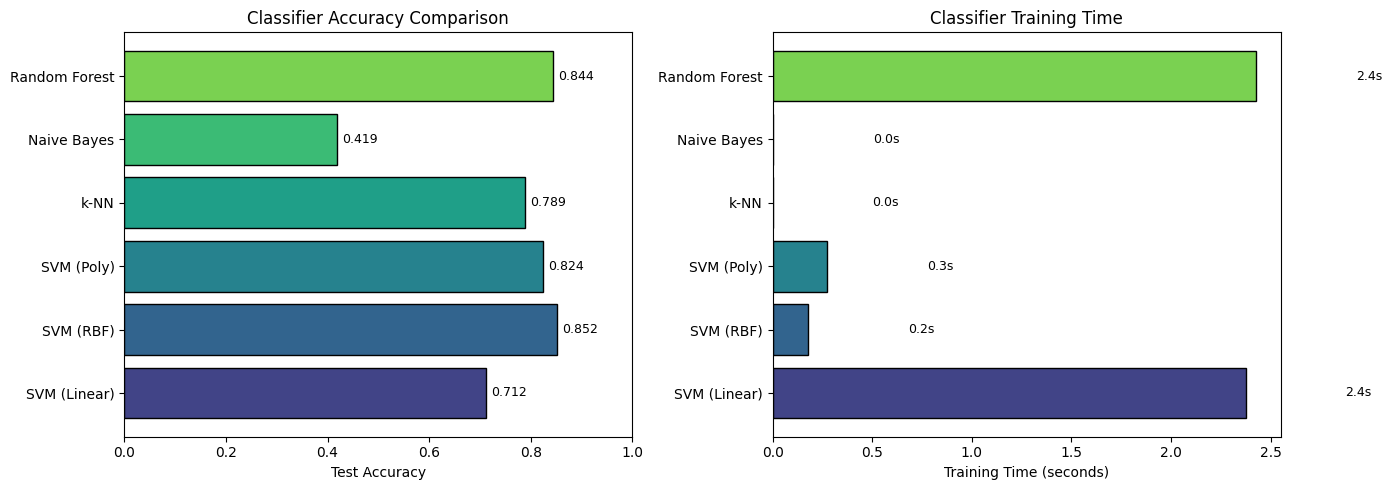

In [114]:
print("TASK 1.1: Benchmarking Classifiers")

classifiers = {
    # Linear Models
    # "Logistic Regression": {
    #     "model": LogisticRegression(max_iter=10000, random_state=42),
    #     "params": {"C": [0.1, 1, 10, 100]},
    #     "description": "Linear Logistic Regression with L2 regularization"
    # },
    "SVM (Linear)": {
        "model": SVC(kernel='linear', random_state=42),
        "params": {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
        "description": "Linear Soft-margin SVM"
    },

    # # Non-Linear Models (Transformed/Kernelized)
    # "Logistic Regression (Poly)": {
    #     "model": Pipeline([
    #         ('poly', PolynomialFeatures(include_bias=False)),
    #         ('clf', LogisticRegression(max_iter=10000, random_state=42))
    #     ]),
    #     "params": {
    #         "poly__degree": [2, 3],
    #         "clf__C": [0.1, 1, 10, 100]
    #     },
    #     "description": "Polynomial Logistic Regression (Grid Search Degree 2 vs 3)"
    # },
    "SVM (RBF)": {
        "model": SVC(kernel='rbf', random_state=42),
        "params": {"C": [0.1, 1, 10, 100], "gamma": ['scale', 'auto', 0.01, 0.1]},
        "description": "SVM with RBF Kernel"
    },
    "SVM (Poly)": {
        "model": SVC(kernel='poly', random_state=42),
        "params": {"degree": [2, 3], "C": [0.1, 1, 10, 100], "gamma": ['scale', 'auto']},
        "description": "SVM with Polynomial Kernel"
    },

    # Other Classifiers
    "k-NN": {
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": [3, 5, 7, 9, 11, 15], "weights": ['uniform', 'distance'], "metric": ['euclidean', 'manhattan']},
        "description": "k-NN with hyperparameter tuning"
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {"var_smoothing": [1e-9, 1e-8, 1e-7]},
        "description": "Gaussian Naive Bayes"
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20, 30]},
        "description": "Random Forest Ensemble"
    }
}

results = []
trained_models = {}

for name, config in classifiers.items():
    
    # Pipeline handles transformations, so we just pass X_train
    X_tr, X_te = X_train, X_test
    
    # GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(config["model"], config["params"], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_tr, y_train)
    
    # Measure training time of the BEST model only (excluding grid search)
    best_model = grid_search.best_estimator_
    start_time = time.time()
    best_model.fit(X_tr, y_train)
    train_time = time.time() - start_time
    
    # Evaluate
    y_pred = best_model.predict(X_te)
    
    results.append({
        "Classifier": name,
        "Best Params": str(grid_search.best_params_),
        "CV Accuracy": round(grid_search.best_score_, 4),
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Training Time (s)": round(train_time, 4)
    })
    trained_models[name] = best_model

# Display results table
results_df = pd.DataFrame(results)
print("\nCLASSIFIER BENCHMARK RESULTS")
print(results_df.to_string(index=False))

# Visualization: Classifier Benchmark
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for accuracy comparison
ax1 = axes[0]
clf_names = [r['Classifier'] for r in results]
clf_accs = [r['Test Accuracy'] for r in results]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(clf_names)))
bars = ax1.barh(clf_names, clf_accs, color=colors, edgecolor='black')
ax1.set_xlabel('Test Accuracy')
ax1.set_title('Classifier Accuracy Comparison')
ax1.set_xlim(0, 1)
for bar, acc in zip(bars, clf_accs):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{acc:.3f}', va='center', fontsize=9)

# Bar plot for training time
ax2 = axes[1]
train_times = [r['Training Time (s)'] for r in results]
bars2 = ax2.barh(clf_names, train_times, color=colors, edgecolor='black')
ax2.set_xlabel('Training Time (seconds)')
ax2.set_title('Classifier Training Time')
for bar, t in zip(bars2, train_times):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{t:.1f}s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('classifier_benchmark.png', dpi=150)

## TASK 1.2

In [115]:
class SoftMarginSVMScratch:
    
    def __init__(self, C=1.0):
        self.C = C
        self.w = None
        self.b = None
        self.support_vectors = None
        self.support_vector_indices = None
        self.support_vector_labels = None
        self.slack_variables = None
        
    def fit(self, X, y, sample_ids=None):
        N, d = X.shape
        
        # Convert labels to {-1, +1} if not already
        unique_labels = np.unique(y)
        y_binary = np.where(y == unique_labels[0], -1, 1).astype(float)
        
        # Construct QP Problem: 
        
        # --- Construct Q matrix (from slides) ---
        
        Q = np.zeros((1 + d + N, 1 + d + N))
        Q[1:d+1, 1:d+1] = np.eye(d)  # I_d for w^T w term
        
        # --- Construct p vector (from slides) ---
        p = np.zeros(1 + d + N)
        p[1+d:] = self.C  # C for each ε_n
        
        # --- Construct constraint matrix A and vector c ---
        
        # Total constraints: N (margin constraints) + N (non-negativity) = 2N
        A = np.zeros((2*N, 1 + d + N))
        c = np.zeros(2*N)
        
        # First N rows: margin constraints y_n(w^T x_n + b) ≥ 1 - ε_n
        for n in range(N):
            A[n, 0] = y_binary[n]           # coefficient for b
            A[n, 1:d+1] = y_binary[n] * X[n]  # coefficients for w
            A[n, 1+d+n] = 1.0               # coefficient for ε_n
            c[n] = 1.0
        
        # Next N rows: non-negativity constraints ε_n ≥ 0
        for n in range(N):
            A[N+n, 1+d+n] = 1.0  # ε_n ≥ 0
            c[N+n] = 0.0
        
        # =====================================================================
        # Solve QP Problem using cvxopt
        # =====================================================================
        
        # Convert to cvxopt matrix format
        Q_cvx = matrix(Q)
        p_cvx = matrix(p)
        # cvxopt uses G u <= h, but we have A u >= c
        # So we use: -A u <= -c
        G_cvx = matrix(-A)
        h_cvx = matrix(-c)
        
        # Solve
        sol = solvers.qp(Q_cvx, p_cvx, G_cvx, h_cvx)
        
        if sol['status'] != 'optimal':
            print(f"Warning: QP solver status: {sol['status']}")
        
        # Extract solution
        u_opt = np.array(sol['x']).flatten()
        
        self.b = u_opt[0]
        self.w = u_opt[1:d+1]
        self.slack_variables = u_opt[1+d:]
   
        #print(f"  Status: {sol['status']}")
        #print(f"  Optimal value: {sol['primal objective']:.6f}")
        
        # =====================================================================
        # Find Support Vectors
        # =====================================================================
        
        margins = y_binary * (X @ self.w + self.b)
        
        # Use tolerance for numerical stability
        tolerance = 1e-4
        sv_mask = (margins <= 1 + tolerance) | (self.slack_variables > tolerance)
        
        self.support_vector_indices = np.where(sv_mask)[0]
        self.support_vectors = X[sv_mask]
        self.support_vector_labels = y[sv_mask]
        
        #print(f"Bias term: b* = {self.b:.6f}")
        #print(f"Weight vector: w* = {self.w}")
        #print(f"  ||w*|| = {np.linalg.norm(self.w):.6f}")
        print(f"\nMargin = {1/np.linalg.norm(self.w):.6f}")
        
        print(f"\nSlack variables (ε):")
        print(f"  Total violation: Σε = {np.sum(self.slack_variables):.6f}")
        print(f"  Max slack: {np.max(self.slack_variables):.6f}")
        print(f"  Points with slack > 0: {np.sum(self.slack_variables > tolerance)}")
        
        print(f"\nSupport Vectors:")
        print(f"  Number of support vectors: {len(self.support_vector_indices)}")
        if sample_ids is not None:
            print(f"  Indices: {sample_ids[self.support_vector_indices].tolist()}")
        else:
            print(f"  Indices: {self.support_vector_indices.tolist()}")
        
        # Find points on exact margin (y(w^T x + b) = 1)
        on_margin = np.abs(margins - 1) < tolerance
        print(f"  Points exactly on margin: {np.sum(on_margin)}")
        
        # Find misclassified points (y(w^T x + b) < 0)
        misclassified_mask = margins < 0
        num_misclassified = np.sum(misclassified_mask)
        print(f"  Misclassified points: {num_misclassified}")
        if num_misclassified > 0:
            misclassified_indices = np.where(misclassified_mask)[0]
            if sample_ids is not None:
                print(f"  Misclassified indices: {sample_ids[misclassified_indices].tolist()}")
            else:
                print(f"  Misclassified indices: {misclassified_indices.tolist()}")
        
        return self
    
    def predict(self, X):
        """Predict class labels."""
        return np.sign(X @ self.w + self.b)
    
    def decision_function(self, X):
        """Compute decision function values."""
        return X @ self.w + self.b
    
    def get_farthest_points(self, X, y, sample_ids=None):
        # Distance to hyperplane: |w^T x + b| / ||w||
        distances = np.abs(self.decision_function(X)) / np.linalg.norm(self.w)
        
        farthest_indices = {}
        farthest_distances = {}
        
        for label in np.unique(y):
            mask = (y == label)
            class_distances = distances[mask]
            class_indices = np.where(mask)[0]
            
            farthest_idx_in_class = np.argmax(class_distances)
            internal_idx = class_indices[farthest_idx_in_class]
            
            if sample_ids is not None:
                farthest_indices[label] = sample_ids[internal_idx]
            else:
                farthest_indices[label] = internal_idx
                
            farthest_distances[label] = class_distances[farthest_idx_in_class]
        
        return farthest_indices, farthest_distances


In [116]:
y = df_labels.to_numpy().flatten()
indices = df_labels.index.to_numpy() # Get original sample IDs

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_image)

print(f"Total samples: {len(X_scaled)}")
all_classes = np.unique(y)
print(f"All classes ({len(all_classes)}): {all_classes}")

Total samples: 3071
All classes (5): ['apple' 'banana' 'mandarin' 'onion' 'potato']


In [117]:
df_assignment = pd.read_csv("assignment_data.csv")
id_to_image = dict(zip(df_assignment['id'], df_assignment['image_path']))

def get_url(sample_id):
    url = id_to_image[sample_id]
    return url

In [118]:
class_pairs = list(combinations(all_classes, 2))

# Store results for all pairs
all_pair_results = []
all_pair_svms = {}

C_default = 1.0  # Use C=1.0 for all pair comparisons

for pair_idx, (class_a, class_b) in enumerate(class_pairs):
    print(f"\n{'#'*70}")
    print(f"CLASS PAIR {pair_idx + 1}: {class_a} vs {class_b}")
    print(f"{'#'*70}")
    
    # Filter data for this pair
    binary_mask = np.isin(y, [class_a, class_b])
    X_pair = X_scaled[binary_mask]
    y_pair = y[binary_mask]
    
    # Create numeric labels: class_a -> +1, class_b -> -1
    y_pair_numeric = np.where(y_pair == class_a, 1.0, -1.0)
    
    print(f"  Class {class_a} ({np.sum(y_pair == class_a)} samples)")
    print(f"  Class {class_b} ({np.sum(y_pair == class_b)} samples)")
    
    # Train SVM
    svm = SoftMarginSVMScratch(C=C_default)
    # Pass the original indices corresponding to this pair
    indices_pair = indices[binary_mask]
    svm.fit(X_pair, y_pair_numeric, sample_ids=indices_pair)
    
    # Compute accuracy
    y_pred = svm.predict(X_pair)
    accuracy = np.mean(y_pred == y_pair_numeric)
    
    # Calculate farthest points for this pair
    farthest_indices, farthest_distances = svm.get_farthest_points(X_pair, y_pair_numeric, sample_ids=indices_pair)
    
    print("\n  Farthest points from hyperplane:")
    for label, idx in farthest_indices.items():
        class_name = class_a if label == 1.0 else class_b
        print(f"    Class {class_name}: Index {idx}, Distance = {farthest_distances[label]:.4f}")
        print(f"    URL: {get_url(idx)}")

    # Analyze SV distances (Inline logic)
    print(f"\n  Cross-class support vector distances:")
    
    # Get support vectors by class from the trained SVM
    sv_pos_mask = svm.support_vector_labels == 1.0
    sv_neg_mask = svm.support_vector_labels == -1.0
    
    sv_pos = svm.support_vectors[sv_pos_mask]
    sv_neg = svm.support_vectors[sv_neg_mask]
    
    min_dist = np.nan
    mean_dist = np.nan
    max_dist = np.nan
    
    if len(sv_pos) > 0 and len(sv_neg) > 0:
        dists = cdist(sv_pos, sv_neg, metric='euclidean')
        min_dist = dists.min()
        mean_dist = dists.mean()
        max_dist = dists.max()
        
        print(f"    Min distance: {min_dist:.4f}")
        print(f"    Mean distance: {mean_dist:.4f}")
        print(f"    Max distance: {max_dist:.4f}")
        
        # Find closest pair
        min_idx = np.unravel_index(dists.argmin(), dists.shape)
        
        pos_indices_in_X = svm.support_vector_indices[sv_pos_mask]
        neg_indices_in_X = svm.support_vector_indices[sv_neg_mask]
        
        closest_pos_idx_in_X = pos_indices_in_X[min_idx[0]]
        closest_neg_idx_in_X = neg_indices_in_X[min_idx[1]]
        
        # 2. Get original IDs
        id_1 = indices_pair[closest_pos_idx_in_X]
        id_2 = indices_pair[closest_neg_idx_in_X]
        
        print(f"    Closest support vectors:")
        print(f"        Class {class_a}: Index {id_1}")
        print(f"        URL: {get_url(id_1)}")
        print(f"        Class {class_b}: Index {id_2}")
        print(f"        URL: {get_url(id_2)}")
    else:
        print("    Not enough support vectors to calculate distances.")

    # Store results
    all_pair_results.append({
        'Class_A': class_a,
        'Class_B': class_b,
        'Samples_A': np.sum(y_pair == class_a),
        'Samples_B': np.sum(y_pair == class_b),
        'Num_SV': len(svm.support_vector_indices),
        'SV_Percent': 100 * len(svm.support_vector_indices) / len(y_pair),
        'Total_Slack': np.sum(svm.slack_variables),
        'Margin': 1 / np.linalg.norm(svm.w),
        'Accuracy': accuracy,
        'Min_SV_Dist': min_dist,
        'Mean_SV_Dist': mean_dist
    })
    
    all_pair_svms[(class_a, class_b)] = {
        'svm': svm,
        'X': X_pair,
        'y': y_pair,
        'y_numeric': y_pair_numeric,
        'sample_ids': indices_pair
    }

# Find easiest and hardest pairs to separate
pair_results_df = pd.DataFrame(all_pair_results)
print(f"\n{'='*70}")
print("ANALYSIS: EASIEST AND HARDEST CLASS PAIRS")
print(f"{'='*70}")

sorted_by_accuracy = pair_results_df.sort_values('Accuracy', ascending=True)
print("\nLowest to highest accuracy:")
print(sorted_by_accuracy[['Class_A', 'Class_B', 'Accuracy', 'Margin', 'Num_SV', 'Min_SV_Dist']].to_string(index=False))

sorted_by_margin = pair_results_df.sort_values('Margin', ascending=True)
print("\nSmallest to largest margin:")
print(sorted_by_margin[['Class_A', 'Class_B', 'Margin', 'Accuracy', 'SV_Percent', 'Min_SV_Dist']].to_string(index=False))

sorted_by_dist = pair_results_df.sort_values('Min_SV_Dist', ascending=True)
print("\nSmallest to largest support vector distance:")
print(sorted_by_dist[['Class_A', 'Class_B', 'Min_SV_Dist', 'Accuracy', 'Margin']].to_string(index=False))



######################################################################
CLASS PAIR 1: apple vs banana
######################################################################
  Class apple (609 samples)
  Class banana (504 samples)

Margin = 0.119776

Slack variables (ε):
  Total violation: Σε = 216.661037
  Max slack: 5.651332
  Points with slack > 0: 280

Support Vectors:
  Number of support vectors: 294
  Indices: [80, 83, 87, 88, 118, 122, 139, 140, 143, 146, 147, 155, 163, 165, 167, 272, 274, 297, 300, 301, 302, 304, 306, 307, 308, 309, 406, 409, 410, 411, 413, 417, 418, 420, 422, 427, 430, 431, 435, 436, 442, 497, 502, 551, 580, 628, 634, 704, 705, 707, 708, 709, 710, 711, 712, 714, 715, 716, 717, 718, 719, 721, 723, 725, 726, 729, 730, 731, 735, 738, 739, 741, 743, 744, 752, 753, 754, 760, 765, 776, 785, 786, 787, 788, 791, 792, 794, 797, 798, 800, 801, 802, 803, 815, 818, 819, 821, 823, 825, 840, 841, 842, 844, 845, 849, 851, 852, 853, 854, 862, 869, 871, 874, 875, 876, 877, 878,

In [119]:
def svm_outlier_detection(svm, indices_pair):
    slack = svm.slack_variables

    Q1 = np.percentile(slack, 25)
    Q3 = np.percentile(slack, 75)
    IQR = Q3 - Q1
    threshold = Q3 + 1.5 * IQR
    outlier_mask = slack > threshold
    internal_ids = np.where(outlier_mask)[0]
    outlier_ids_svm = indices_pair[internal_ids].tolist()

    print(f"\nOutliers detected (slack > {threshold}): {len(outlier_ids_svm)}")
    print(f"Outlier IDs: {outlier_ids_svm[:20]}...")  # First 20

    # Sort by slack value (most severe first)
    sorted_by_slack = np.argsort(slack)[::-1]
    print("\nTop 10 most severe outliers (highest slack):")
    for i in range(min(10, len(sorted_by_slack))):
        idx = sorted_by_slack[i]
        print(f"  ID: {indices_pair[idx]}, Slack: {slack[idx]:.4f}")
        print(f"    {get_url(indices_pair[idx])}")
    return outlier_ids_svm


### SVM OUTLIERS

In [120]:
def visualize_svm_outliers(X_pair, y_pair_numeric, class_a, class_b, indices_pair, svm):
    # Get outliers for this pair
    slack = svm.slack_variables
    Q1, Q3 = np.percentile(slack, 25), np.percentile(slack, 75)
    threshold = Q3 + 1.5 * (Q3 - Q1)
    outlier_mask = slack > threshold
    outlier_indices = np.where(outlier_mask)[0]
    
    # PCA projection
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_pair)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: PCA with outliers
    ax1 = axes[0]
    pos_mask = y_pair_numeric == 1.0
    neg_mask = y_pair_numeric == -1.0
    
    ax1.scatter(X_2d[pos_mask & ~outlier_mask, 0], X_2d[pos_mask & ~outlier_mask, 1], 
                c='red', alpha=0.4, s=30, label=f'{class_a}')
    ax1.scatter(X_2d[neg_mask & ~outlier_mask, 0], X_2d[neg_mask & ~outlier_mask, 1], 
                c='blue', alpha=0.4, s=30, label=f'{class_b}')
    ax1.scatter(X_2d[outlier_indices, 0], X_2d[outlier_indices, 1], 
                c='yellow', edgecolors='black', s=80, linewidths=1,
                marker='X', label=f'Outliers ({len(outlier_indices)})', zorder=10)
    
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_title(f'SVM Outliers: {class_a} vs {class_b}')
    ax1.legend(loc='upper right')

    # Plot 2: Slack bar chart
    ax2 = axes[1]
    slack_sorted = np.sort(slack)[::-1]
    colors = ['red' if s > threshold else 'gray' for s in slack_sorted]
    ax2.bar(range(len(slack_sorted)), slack_sorted, color=colors, alpha=0.8, width=1.0)
    ax2.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold:.2f}')
    ax2.set_xlabel('Points (sorted by slack)')
    ax2.set_ylabel('Slack Variable ε')
    ax2.set_title(f'Slack Variables - {len(outlier_indices)} Outliers')
    ax2.legend()

    plt.tight_layout()
    plt.show()


Outliers detected (slack > 0.026412929997968876): 274
Outlier IDs: [83, 87, 88, 118, 122, 139, 140, 143, 146, 147, 155, 167, 272, 274, 297, 300, 301, 302, 304, 306]...

Top 10 most severe outliers (highest slack):
  ID: 1678, Slack: 5.6513
    https://drive.google.com/file/d/1ZCuj15LJto0Gu3YfF5ANEllgNnmn7auV/view?usp=drivesdk
  ID: 1904, Slack: 4.0376
    https://drive.google.com/file/d/1XGr8d2Yp4zY1Wd1g0eGgHyue3lm-Wt6U/view?usp=drivesdk
  ID: 896, Slack: 3.8026
    https://drive.google.com/file/d/1wnVp9Wq45QtgTKI-S2mzwlH-OWgUonwN/view?usp=drivesdk
  ID: 1937, Slack: 3.0258
    https://drive.google.com/file/d/1kZuJjqF7paQZ8E_5_6UlHie5q7MLuXVc/view?usp=drivesdk
  ID: 1714, Slack: 2.8291
    https://drive.google.com/file/d/1r9CN2PL5-5yEtDnDGEAJvnRqanKF8dXB/view?usp=drivesdk
  ID: 1852, Slack: 2.4480
    https://drive.google.com/file/d/1kA5Q3UCvHvIretCsAa_xjPgKHKAYioPG/view?usp=drivesdk
  ID: 981, Slack: 2.3400
    https://drive.google.com/file/d/1SmGa90An2evPOpREmDO3aOmCqTs9LdA8/view?us

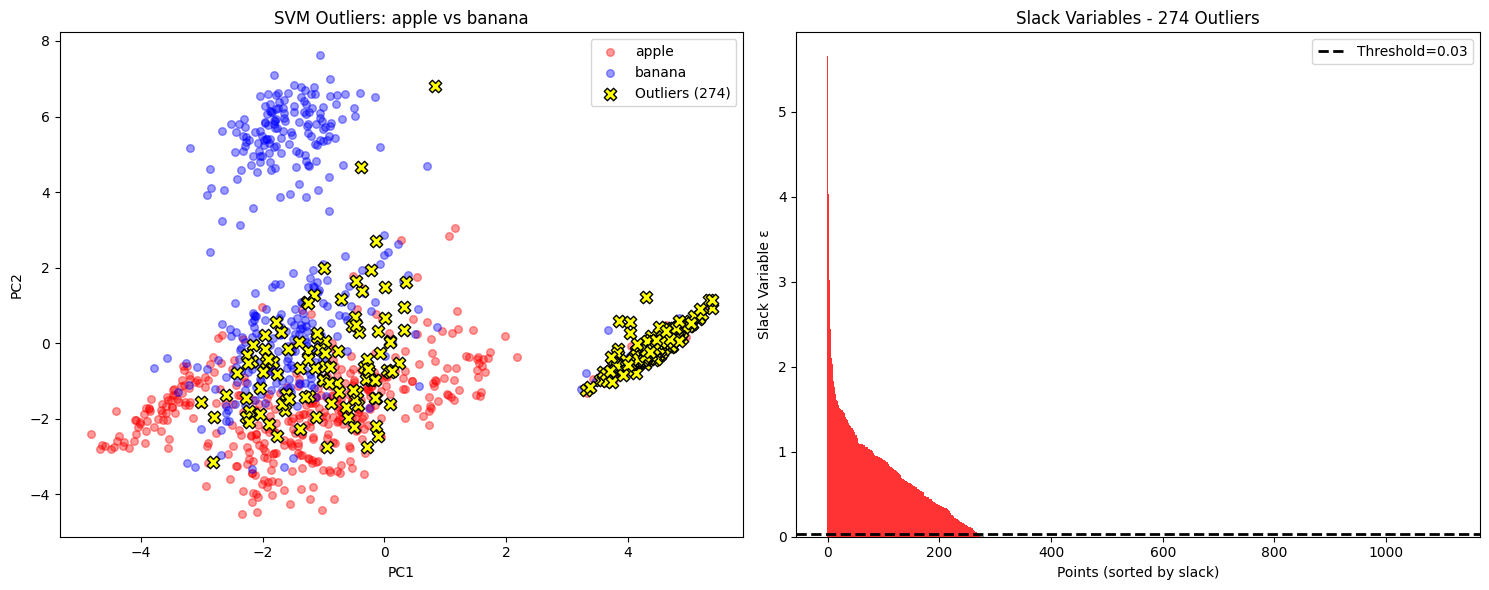


Outliers detected (slack > 1.6236307294046273): 78
Outlier IDs: [83, 274, 331, 363, 365, 367, 383, 551, 580, 627, 628, 685, 705, 707, 708, 709, 710, 712, 713, 714]...

Top 10 most severe outliers (highest slack):
  ID: 1079, Slack: 4.6799
    https://drive.google.com/file/d/1c4c9C3FDHhiqBiDWuG6UXIGv6jtwj84w/view?usp=drivesdk
  ID: 1523, Slack: 4.0548
    https://drive.google.com/file/d/1Gp72JT1a0hCd5XHYJ9Ka1sLugeZf2a35/view?usp=drivesdk
  ID: 1041, Slack: 3.4180
    https://drive.google.com/file/d/1gOY2KhLPAHNr6oTtHjJ2cMhtGuKZALUD/view?usp=drivesdk
  ID: 1064, Slack: 3.3030
    https://drive.google.com/file/d/18HQBIZZgNgGdd7ZuONgNZHaJctg-zHS_/view?usp=drivesdk
  ID: 1082, Slack: 3.2827
    https://drive.google.com/file/d/1w3Ct01xpdUBMyl4q_KhQDAfgZjaAwh9f/view?usp=drivesdk
  ID: 1291, Slack: 3.2753
    https://drive.google.com/file/d/1Cqwk0pIqmOjegDzm2cxvlV46bjidL8AP/view?usp=drivesdk
  ID: 580, Slack: 3.1296
    https://drive.google.com/file/d/1ZzpS1UI5a5lrPLEct9VaJGxo306fgsb6/view?us

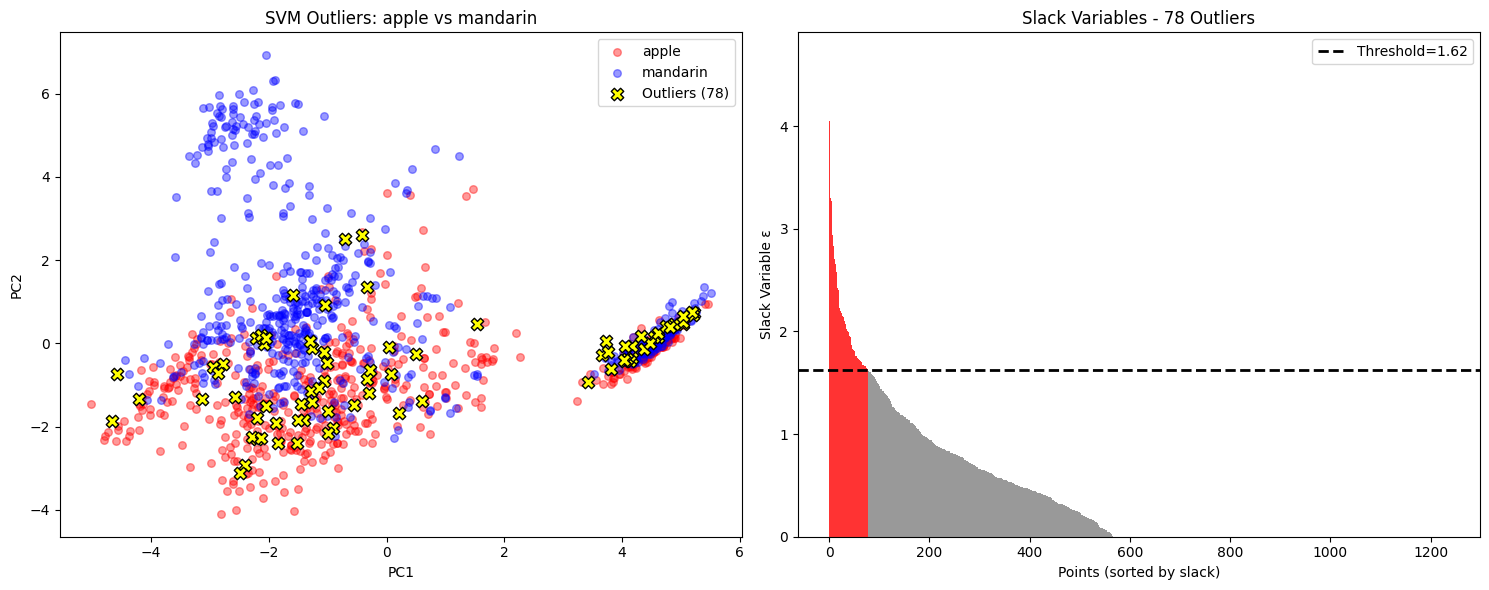


Outliers detected (slack > 2.4468175748543044): 16
Outlier IDs: [94, 474, 749, 750, 755, 761, 769, 774, 814, 837, 865, 901, 908, 917, 919, 2977]...

Top 10 most severe outliers (highest slack):
  ID: 865, Slack: 3.3882
    https://drive.google.com/file/d/1Z9j_ICqdNoPRnbdK17IlgVmA0tStK-_g/view?usp=drivesdk
  ID: 919, Slack: 3.0592
    https://drive.google.com/file/d/1_wbSufEBuHdA0Yj-LaEqxuAlCeT_SXso/view?usp=drivesdk
  ID: 917, Slack: 2.9675
    https://drive.google.com/file/d/1SHHYGFgMi8PUqYrg0zRIskXyAL27sRkL/view?usp=drivesdk
  ID: 755, Slack: 2.9566
    https://drive.google.com/file/d/1KPWH2JK08GabipwxWY5g-fm0bmOO2EW-/view?usp=drivesdk
  ID: 814, Slack: 2.8374
    https://drive.google.com/file/d/1H-9FRILnJTAYuxJoAf7P7QCGyYq9mbLM/view?usp=drivesdk
  ID: 774, Slack: 2.6498
    https://drive.google.com/file/d/1cR_CCzbT16XjBa-UKTnZXScQA8gJj8hs/view?usp=drivesdk
  ID: 94, Slack: 2.6354
    https://drive.google.com/file/d/1fhr55SO9iOy26wfW9kXZrTU_v5qte7Ey/view?usp=drivesdk
  ID: 761, Slac

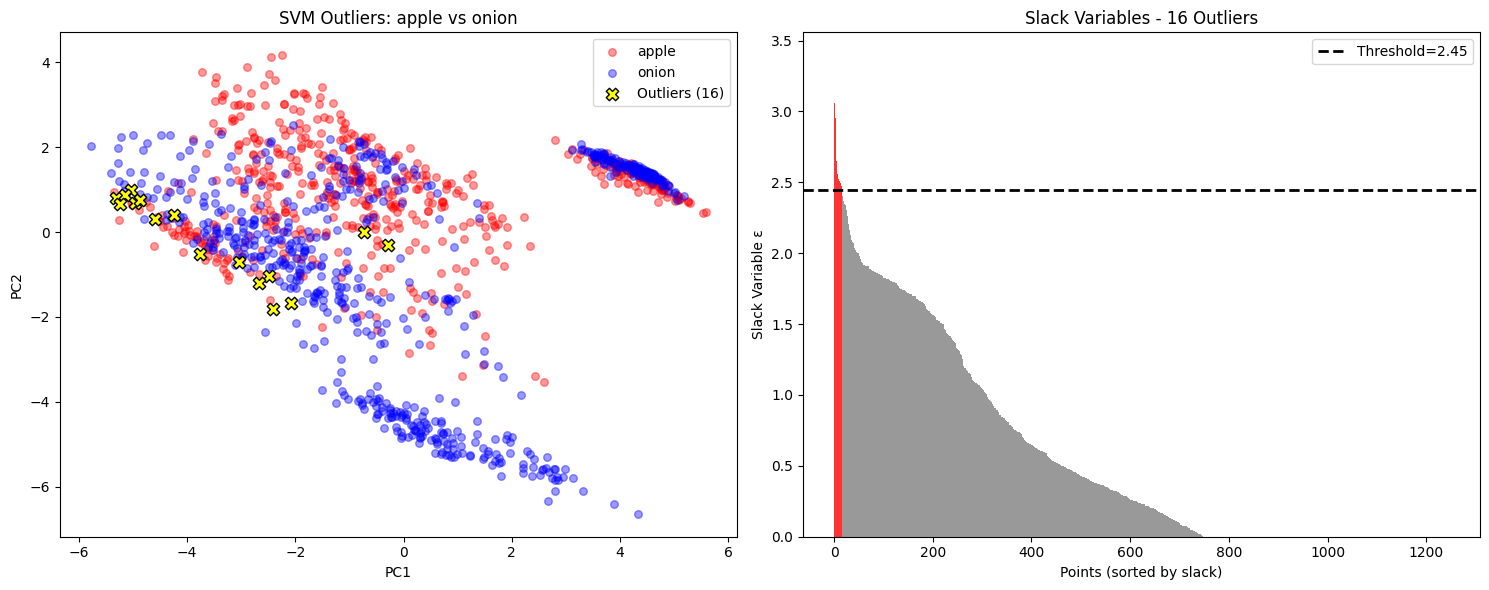


Outliers detected (slack > 2.1882905024942048): 17
Outlier IDs: [550, 646, 649, 681, 685, 723, 755, 865, 892, 896, 919, 923, 930, 944, 964, 981, 1986]...

Top 10 most severe outliers (highest slack):
  ID: 896, Slack: 3.7819
    https://drive.google.com/file/d/1wnVp9Wq45QtgTKI-S2mzwlH-OWgUonwN/view?usp=drivesdk
  ID: 1986, Slack: 3.6398
    https://drive.google.com/file/d/1XV8fzugeB12_2LoBsiU5bV1vhlA5bnA7/view?usp=drivesdk
  ID: 964, Slack: 3.4876
    https://drive.google.com/file/d/1mh50uw_TGPGwXx2xqKuBueVIeAY-KLmE/view?usp=drivesdk
  ID: 981, Slack: 3.0566
    https://drive.google.com/file/d/1SmGa90An2evPOpREmDO3aOmCqTs9LdA8/view?usp=drivesdk
  ID: 646, Slack: 3.0209
    https://drive.google.com/file/d/10HDxIaqK4I8WFxgfxMayZH_C4iTsp0Al/view?usp=drivesdk
  ID: 685, Slack: 2.9213
    https://drive.google.com/file/d/1ukZeSpGebQ7Pyyjf20qZCcBBtvKWf02D/view?usp=drivesdk
  ID: 681, Slack: 2.8090
    https://drive.google.com/file/d/1o4T98WiWzWux0lxi0uXLMNTX9Urg5p5r/view?usp=drivesdk
  ID: 9

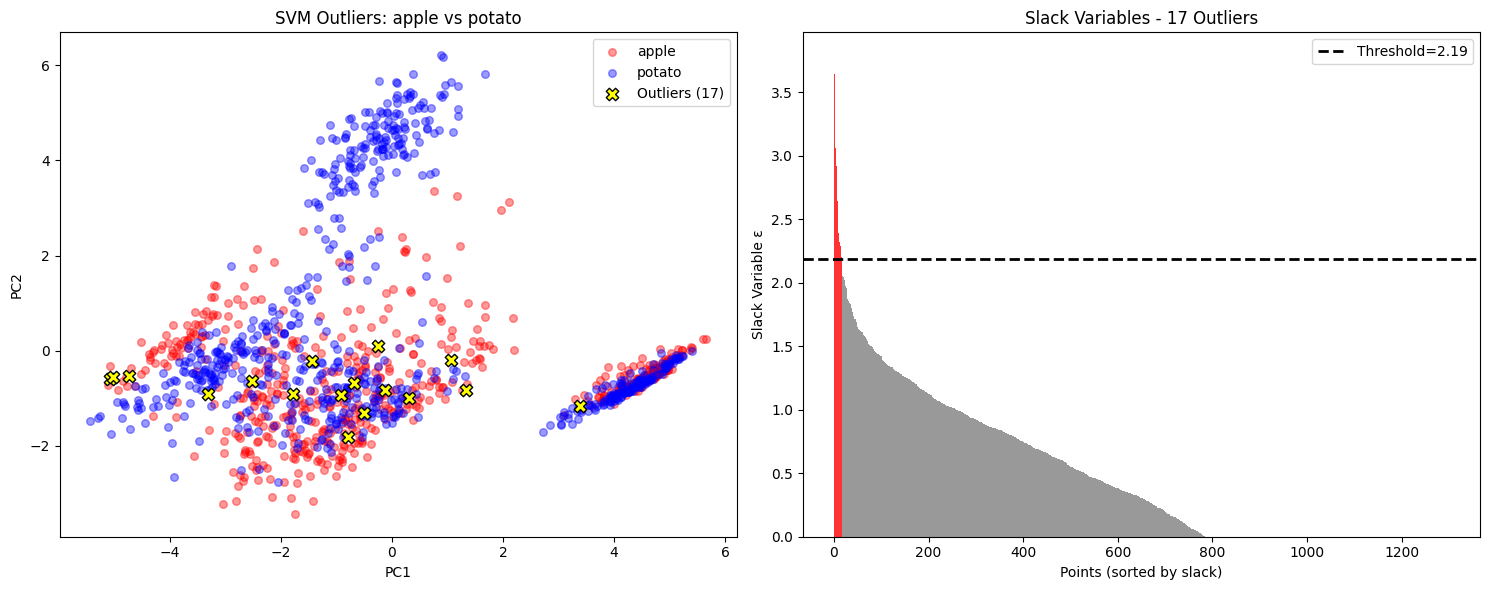


Outliers detected (slack > 1.2943668574705662): 107
Outlier IDs: [254, 257, 344, 345, 354, 355, 373, 376, 1192, 1204, 1205, 1206, 1265, 1266, 1285, 1287, 1304, 1349, 1351, 1354]...

Top 10 most severe outliers (highest slack):
  ID: 1678, Slack: 6.5673
    https://drive.google.com/file/d/1ZCuj15LJto0Gu3YfF5ANEllgNnmn7auV/view?usp=drivesdk
  ID: 1489, Slack: 5.0467
    https://drive.google.com/file/d/104EL2S1Bm7y5P9PviKhQ1V4sAx6GxN0K/view?usp=drivesdk
  ID: 1470, Slack: 5.0038
    https://drive.google.com/file/d/1-6lFVLBZJSXXh0QEtLiAu3zDqG4kcEn0/view?usp=drivesdk
  ID: 1495, Slack: 4.8051
    https://drive.google.com/file/d/1FDw34Ye8rLAL0ikSMYJ5r-8cDpVRMW_v/view?usp=drivesdk
  ID: 1498, Slack: 4.7787
    https://drive.google.com/file/d/1DgI0RbO3RalwG9U_yZ00LNUn_R-5qkC2/view?usp=drivesdk
  ID: 1499, Slack: 4.5452
    https://drive.google.com/file/d/1RkzWshFU3vnqja1GsRhipAhYSPSdNiVA/view?usp=drivesdk
  ID: 1482, Slack: 4.2785
    https://drive.google.com/file/d/1d0DfD3xNPgYMkmuDvaIEomRpy

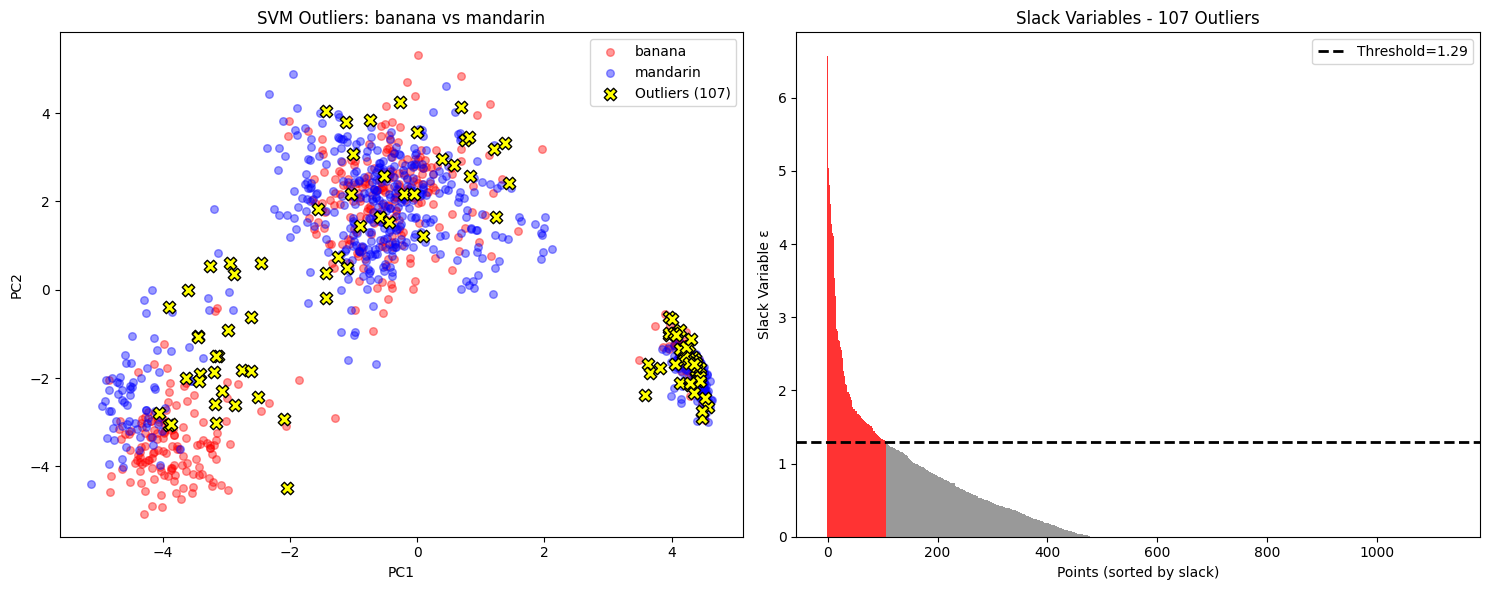


Outliers detected (slack > 1.9112566608957753e-09): 191
Outlier IDs: [15, 50, 53, 140, 149, 167, 471, 473, 1538, 1564, 1570, 1606, 1633, 1654, 1661, 1667, 1669, 1675, 1677, 1678]...

Top 10 most severe outliers (highest slack):
  ID: 1606, Slack: 2.9000
    https://drive.google.com/file/d/1hUQ3vwSZ2apBtvzcWKholwSljkgOgKKN/view?usp=drivesdk
  ID: 1570, Slack: 2.7198
    https://drive.google.com/file/d/1r85JWvHGXQ0SdzL84Eg03T2Sbi4ud5G0/view?usp=drivesdk
  ID: 2670, Slack: 2.6478
    https://drive.google.com/file/d/1AGIqlk5hOoX8FufqfL2fr9f-OoTScizf/view?usp=drivesdk
  ID: 2716, Slack: 2.6414
    https://drive.google.com/file/d/1Vsv_l5ZNf2iBPoWNeBq_DeramdBdKD21/view?usp=drivesdk
  ID: 1538, Slack: 2.1737
    https://drive.google.com/file/d/1Nj88GLHGIgQ1yGaq7nMICK5NmC3jjTop/view?usp=drivesdk
  ID: 1678, Slack: 2.0530
    https://drive.google.com/file/d/1ZCuj15LJto0Gu3YfF5ANEllgNnmn7auV/view?usp=drivesdk
  ID: 1633, Slack: 2.0282
    https://drive.google.com/file/d/1zfwjNC1zI-FMj04hNRXK6otl

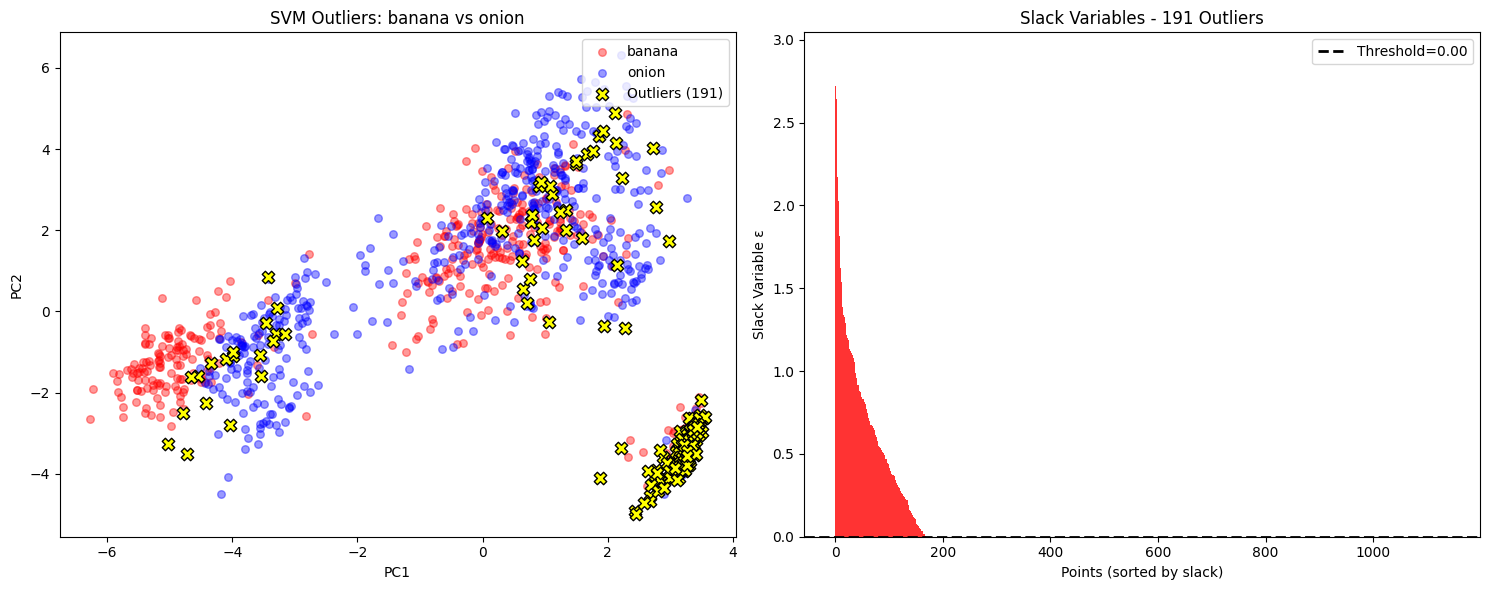


Outliers detected (slack > 3.940966383157722e-09): 238
Outlier IDs: [67, 70, 140, 159, 167, 174, 1538, 1570, 1606, 1633, 1667, 1669, 1675, 1677, 1678, 1681, 1685, 1691, 1694, 1697]...

Top 10 most severe outliers (highest slack):
  ID: 1678, Slack: 4.1508
    https://drive.google.com/file/d/1ZCuj15LJto0Gu3YfF5ANEllgNnmn7auV/view?usp=drivesdk
  ID: 1752, Slack: 2.8607
    https://drive.google.com/file/d/1FJ5GdGTLOgXSXWdZNsAGoidCQCtouITe/view?usp=drivesdk
  ID: 1714, Slack: 2.7362
    https://drive.google.com/file/d/1r9CN2PL5-5yEtDnDGEAJvnRqanKF8dXB/view?usp=drivesdk
  ID: 2425, Slack: 1.9913
    https://drive.google.com/file/d/1v09OdRSOrHaCsqA43-KXM0_lY67UpwS9/view?usp=drivesdk
  ID: 2243, Slack: 1.9851
    https://drive.google.com/file/d/1-hUs_HBjCAgssaP_7Kq98QYOuiN2HzPN/view?usp=drivesdk
  ID: 1701, Slack: 1.9727
    https://drive.google.com/file/d/1j--eBhtox-b4f6HZVAIWCaEU_JKrAQ3E/view?usp=drivesdk
  ID: 2266, Slack: 1.9282
    https://drive.google.com/file/d/1e7AOpSbtYYeoEUc9Qr7ePM

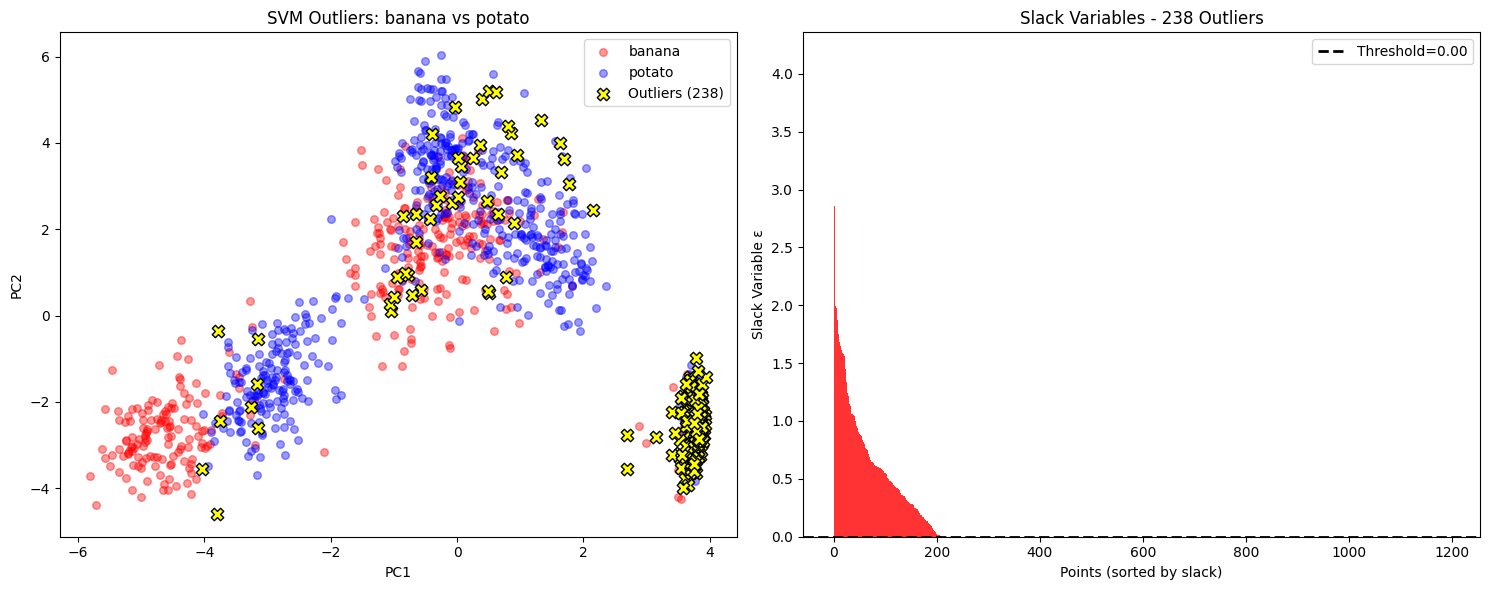


Outliers detected (slack > 0.6871547450647943): 172
Outlier IDs: [9, 13, 14, 15, 244, 249, 250, 251, 252, 254, 257, 471, 472, 473, 474, 478, 479, 1018, 1024, 1071]...

Top 10 most severe outliers (highest slack):
  ID: 1374, Slack: 5.9638
    https://drive.google.com/file/d/1SpgYPYm937WLg8MKTO1mwtjr1jVe6_R4/view?usp=drivesdk
  ID: 1523, Slack: 5.6023
    https://drive.google.com/file/d/1Gp72JT1a0hCd5XHYJ9Ka1sLugeZf2a35/view?usp=drivesdk
  ID: 1461, Slack: 4.4108
    https://drive.google.com/file/d/1X-2qQVkV9yIOuT-YciXyfY4rzsKpYKDs/view?usp=drivesdk
  ID: 2670, Slack: 4.0413
    https://drive.google.com/file/d/1AGIqlk5hOoX8FufqfL2fr9f-OoTScizf/view?usp=drivesdk
  ID: 1372, Slack: 3.9522
    https://drive.google.com/file/d/1Q97uRUPvgRAq8tX2RCTbGloWlMkz3Bof/view?usp=drivesdk
  ID: 2936, Slack: 3.0393
    https://drive.google.com/file/d/1kPI4ukPkc_EcH49Pm6u3jgMqVobcwb_R/view?usp=drivesdk
  ID: 1346, Slack: 3.0173
    https://drive.google.com/file/d/1NRiRBqIRmf9h6rJmEEBobzkga2sqw20N/view?u

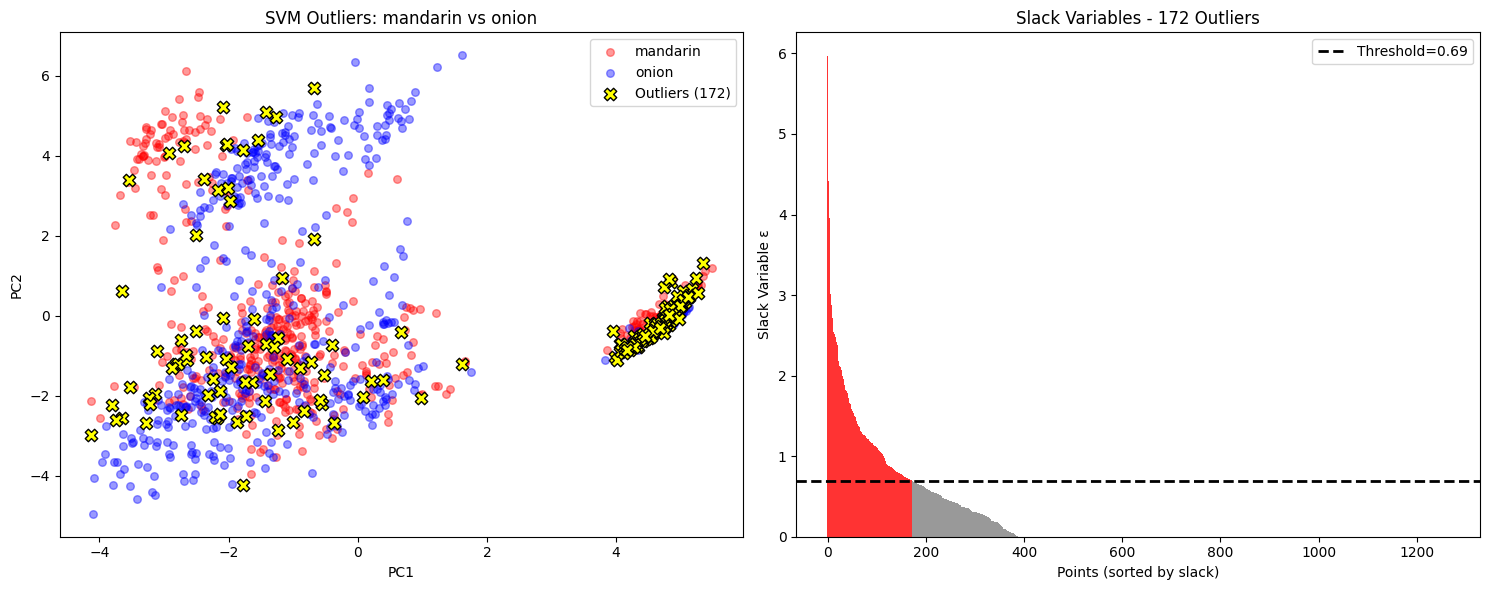


Outliers detected (slack > 1.396639190100672): 59
Outlier IDs: [249, 470, 1018, 1024, 1027, 1063, 1069, 1079, 1135, 1161, 1185, 1236, 1285, 1291, 1346, 1365, 1369, 1372, 1374, 1375]...

Top 10 most severe outliers (highest slack):
  ID: 1374, Slack: 7.6166
    https://drive.google.com/file/d/1SpgYPYm937WLg8MKTO1mwtjr1jVe6_R4/view?usp=drivesdk
  ID: 1523, Slack: 7.2954
    https://drive.google.com/file/d/1Gp72JT1a0hCd5XHYJ9Ka1sLugeZf2a35/view?usp=drivesdk
  ID: 1461, Slack: 5.3978
    https://drive.google.com/file/d/1X-2qQVkV9yIOuT-YciXyfY4rzsKpYKDs/view?usp=drivesdk
  ID: 1955, Slack: 4.9040
    https://drive.google.com/file/d/1brWtuG2nyxXwcjToN-PgxxAFx5T6UDrU/view?usp=drivesdk
  ID: 1372, Slack: 4.7919
    https://drive.google.com/file/d/1Q97uRUPvgRAq8tX2RCTbGloWlMkz3Bof/view?usp=drivesdk
  ID: 1346, Slack: 4.3454
    https://drive.google.com/file/d/1NRiRBqIRmf9h6rJmEEBobzkga2sqw20N/view?usp=drivesdk
  ID: 1375, Slack: 4.0720
    https://drive.google.com/file/d/1g9VWQzjIt4X9L5-cM5o63

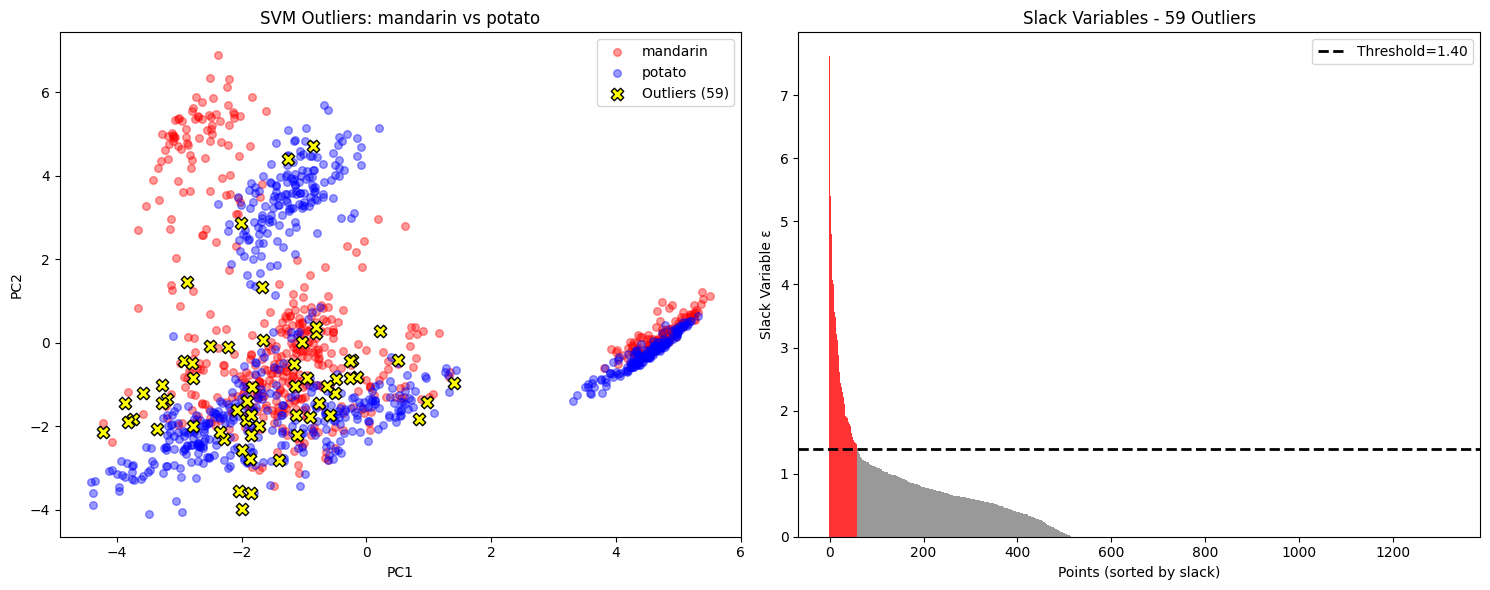


Outliers detected (slack > 2.1020214234598162): 55
Outlier IDs: [244, 248, 471, 472, 473, 478, 480, 1957, 1958, 1963, 1964, 1978, 1983, 2000, 2058, 2061, 2062, 2064, 2092, 2093]...

Top 10 most severe outliers (highest slack):
  ID: 2670, Slack: 4.3655
    https://drive.google.com/file/d/1AGIqlk5hOoX8FufqfL2fr9f-OoTScizf/view?usp=drivesdk
  ID: 2552, Slack: 4.3550
    https://drive.google.com/file/d/1lE3YdN9aX0Fn84nN0sZ7iZAaqmu_HUTQ/view?usp=drivesdk
  ID: 2716, Slack: 4.2006
    https://drive.google.com/file/d/1Vsv_l5ZNf2iBPoWNeBq_DeramdBdKD21/view?usp=drivesdk
  ID: 1983, Slack: 4.0335
    https://drive.google.com/file/d/1tKorm3-MT6u9lrB4aqUIJCdoiA7v4ueu/view?usp=drivesdk
  ID: 2595, Slack: 3.9271
    https://drive.google.com/file/d/1kK-_vSgY-NK_pIUT7N8AhSwrUc1jfwDQ/view?usp=drivesdk
  ID: 2706, Slack: 3.4821
    https://drive.google.com/file/d/1_f8BFifopRH16dvh1YSccdOJR7n4iIYd/view?usp=drivesdk
  ID: 2727, Slack: 3.4758
    https://drive.google.com/file/d/1rMcNwErfxkZSDcqYs-NDOMo1K

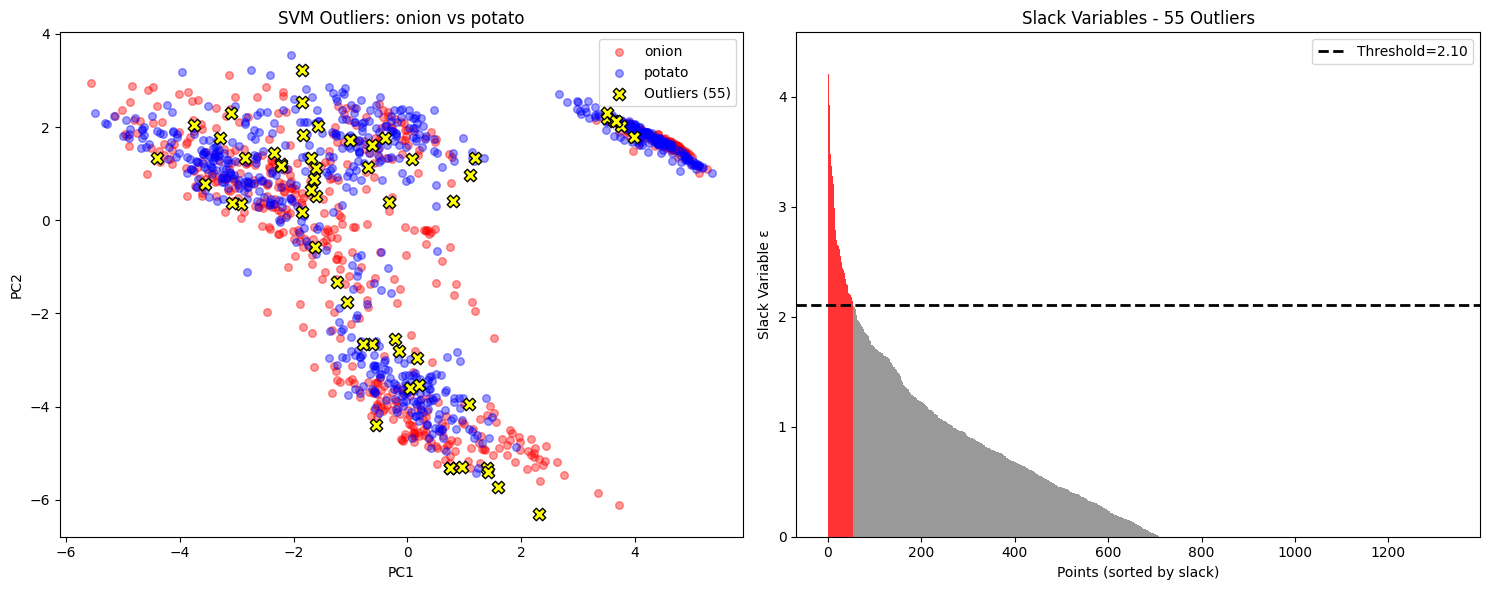

In [121]:
outlier_votes = Counter()

for pair, data in all_pair_svms.items():
    (class_a, class_b) = pair
    svm = data['svm']
    X_pair = data['X']
    y_pair = data['y']
    y_pair_numeric = data['y_numeric']
    indices_pair = data['sample_ids']
    outlier_ids_svm = svm_outlier_detection(svm, indices_pair)
    
    visualize_svm_outliers(X_pair, y_pair_numeric, class_a, class_b, indices_pair, svm)

    for oid in outlier_ids_svm:
        outlier_votes[oid] += 1

In [122]:
min_votes = 3
global_outliers = [(oid, votes) for oid, votes in outlier_votes.items() if votes >= min_votes]
global_outliers.sort(key=lambda x: -x[1])

# Create ID to class mapping
id_to_class = dict(zip(indices, y))
svm_outliers = [oid for oid, votes in global_outliers]

# Count per class
outlier_class_counts = Counter([id_to_class[oid] for oid in svm_outliers])

print(f"Number of SVM outliers (≥{min_votes} pairs): {len(svm_outliers)}")

print(f"\nSVM Outliers per Class:")
for cls in sorted(all_classes):
    count = outlier_class_counts.get(cls, 0)
    total = np.sum(y == cls)
    print(f"  {cls}: {count}/{total} ({100*count/total:.1f}%)")

print(f"\nTop 10 SVM Outliers:")
print("-" * 50)
for oid, votes in global_outliers[:10]:
    print(f"  ID {oid} ({id_to_class[oid]}): {votes}/10 pairs")
    print(f"    {get_url(oid)}")

Number of SVM outliers (≥3 pairs): 111

SVM Outliers per Class:
  apple: 1/609 (0.2%)
  banana: 85/504 (16.9%)
  mandarin: 12/628 (1.9%)
  onion: 13/638 (2.0%)
  potato: 0/692 (0.0%)

Top 10 SVM Outliers:
--------------------------------------------------
  ID 1538 (banana): 4/10 pairs
    https://drive.google.com/file/d/1Nj88GLHGIgQ1yGaq7nMICK5NmC3jjTop/view?usp=drivesdk
  ID 1633 (banana): 4/10 pairs
    https://drive.google.com/file/d/1zfwjNC1zI-FMj04hNRXK6otl7Bkx8_c4/view?usp=drivesdk
  ID 1677 (banana): 4/10 pairs
    https://drive.google.com/file/d/1Wl04COm3AT40C35z8PWXQ1fz-4XnkQcY/view?usp=drivesdk
  ID 1678 (banana): 4/10 pairs
    https://drive.google.com/file/d/1ZCuj15LJto0Gu3YfF5ANEllgNnmn7auV/view?usp=drivesdk
  ID 1691 (banana): 4/10 pairs
    https://drive.google.com/file/d/1pJhyUT1fvDb6UknHgHicPZkg1nwd7I1e/view?usp=drivesdk
  ID 1694 (banana): 4/10 pairs
    https://drive.google.com/file/d/1wSxKoIoLG3ory7MPDfMRLU8FJPjfvV-U/view?usp=drivesdk
  ID 1698 (banana): 4/10 pairs

### K-MEANS OUTLIERS

In [123]:
n_clusters = len(np.unique(y))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Compute distance to assigned centroid for each point
distances = np.min(cdist(X_scaled, kmeans.cluster_centers_), axis=1)

threshold = np.mean(distances) + 2 * np.std(distances)
outlier_mask_kmeans = distances > threshold
outlier_indices_kmeans = np.where(outlier_mask_kmeans)[0]

print(f"Number of K-Means Outliers: {len(outlier_indices_kmeans)}")

# Get outlier IDs
kmeans_outliers = indices[outlier_indices_kmeans].tolist()

# Count per class
id_to_class = dict(zip(indices, y))
kmeans_class_counts = Counter([id_to_class[oid] for oid in kmeans_outliers])

print(f"\nK-Means Outliers per Class:")
for cls in sorted(all_classes):
    count = kmeans_class_counts.get(cls, 0)
    total = np.sum(y == cls)
    print(f"  {cls}: {count}/{total} ({100*count/total:.1f}%)")

# Top 5 outliers (sorted by distance)
outlier_info_kmeans = [(oid, distances[idx], id_to_class[oid]) for idx, oid in zip(outlier_indices_kmeans, kmeans_outliers)]
sorted_outliers_kmeans = sorted(outlier_info_kmeans, key=lambda x: x[1], reverse=True)

print("\nTop 10 K-Means Outliers:")
print("-" * 60)
for oid, dist, cls in sorted_outliers_kmeans[:10]:
    print(f"  ID {oid} ({cls}): Distance = {dist:.4f}")
    print(f"    {get_url(oid)}")


Number of K-Means Outliers: 118

K-Means Outliers per Class:
  apple: 48/609 (7.9%)
  banana: 15/504 (3.0%)
  mandarin: 27/628 (4.3%)
  onion: 24/638 (3.8%)
  potato: 4/692 (0.6%)

Top 10 K-Means Outliers:
------------------------------------------------------------
  ID 1025 (mandarin): Distance = 12.1817
    https://drive.google.com/file/d/1SSFsW55cnrhEFLZ7kj8PdOyHgeae34X4/view?usp=drivesdk
  ID 1960 (potato): Distance = 9.2915
    https://drive.google.com/file/d/1JwarbHSt6ZyWZWinf7xGz6sXfrFud7VU/view?usp=drivesdk
  ID 1067 (mandarin): Distance = 9.2767
    https://drive.google.com/file/d/1FuboJR_j3gDC9lTHVVKgBm8EkWO2dDJ7/view?usp=drivesdk
  ID 1043 (mandarin): Distance = 8.0177
    https://drive.google.com/file/d/1yfy3CezHtVco9bwU8s_Vla4x94DTfeAn/view?usp=drivesdk
  ID 1022 (mandarin): Distance = 7.6449
    https://drive.google.com/file/d/1Mr0Hstj3VjzehEtHLRIF2sf-EEAivQAP/view?usp=drivesdk
  ID 1410 (mandarin): Distance = 7.4363
    https://drive.google.com/file/d/1pUJIobZi4KExWD_1R

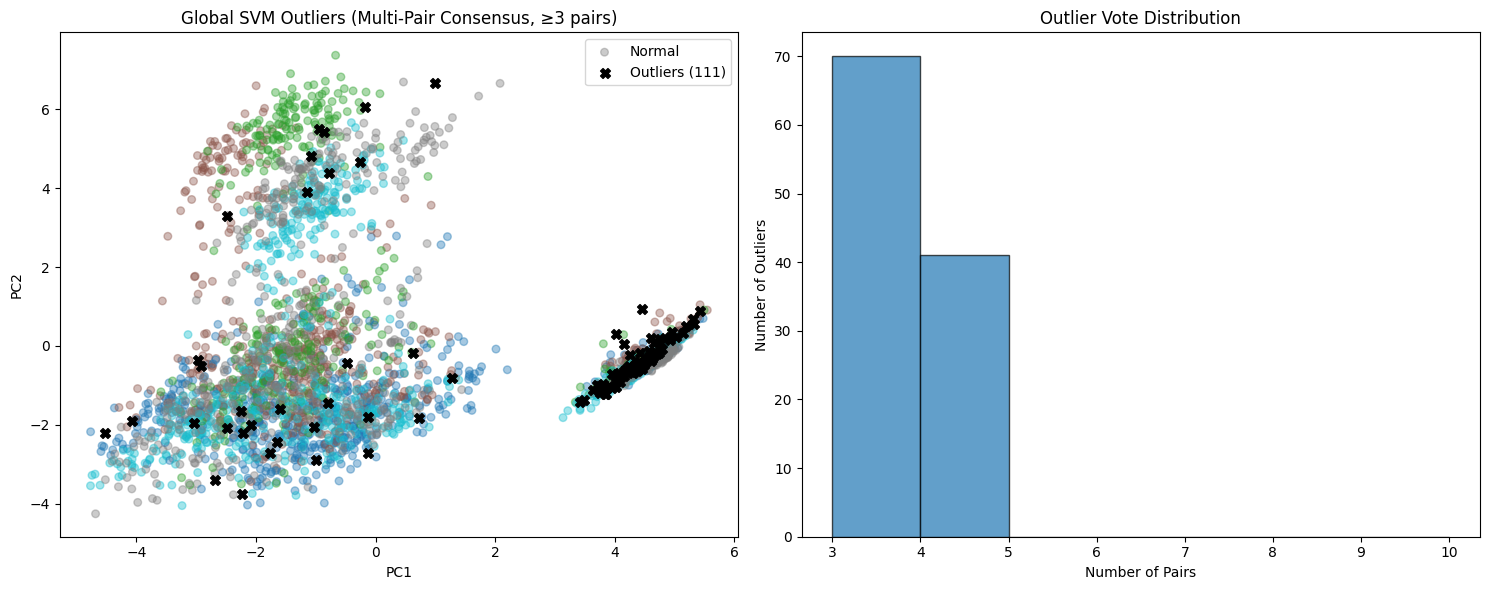

In [127]:
# Visualization: Global SVM Outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Convert global_outliers to mask
svm_outlier_ids = [oid for oid, votes in global_outliers]
id_to_idx = {oid: idx for idx, oid in enumerate(indices)}
svm_outlier_indices = [id_to_idx[oid] for oid in svm_outlier_ids if oid in id_to_idx]
outlier_mask_svm = np.zeros(len(X_scaled), dtype=bool)
outlier_mask_svm[svm_outlier_indices] = True

y_numeric = le.transform(y_raw)

# Plot 1: PCA with outliers
ax1 = axes[0]
pca_svm = PCA(n_components=2)
X_2d_svm = pca_svm.fit_transform(X_scaled)

# Color by true class
ax1.scatter(X_2d_svm[~outlier_mask_svm, 0], X_2d_svm[~outlier_mask_svm, 1], 
            c=y_numeric[~outlier_mask_svm], cmap='tab10', alpha=0.4, s=30, label='Normal')
ax1.scatter(X_2d_svm[outlier_mask_svm, 0], X_2d_svm[outlier_mask_svm, 1], 
            c='black', s=50, linewidths=1,
            marker='X', label=f'Outliers ({len(svm_outlier_indices)})', zorder=10)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title(f'Global SVM Outliers (Multi-Pair Consensus, ≥{min_votes} pairs)')
ax1.legend(loc='upper right')

# Plot 2: Vote distribution
ax2 = axes[1]
votes_list = [votes for oid, votes in global_outliers]
ax2.hist(votes_list, bins=range(min_votes, 11), edgecolor='black', alpha=0.7)
ax2.set_xlabel('Number of Pairs')
ax2.set_ylabel('Number of Outliers')
ax2.set_title('Outlier Vote Distribution')

plt.tight_layout()
plt.show()

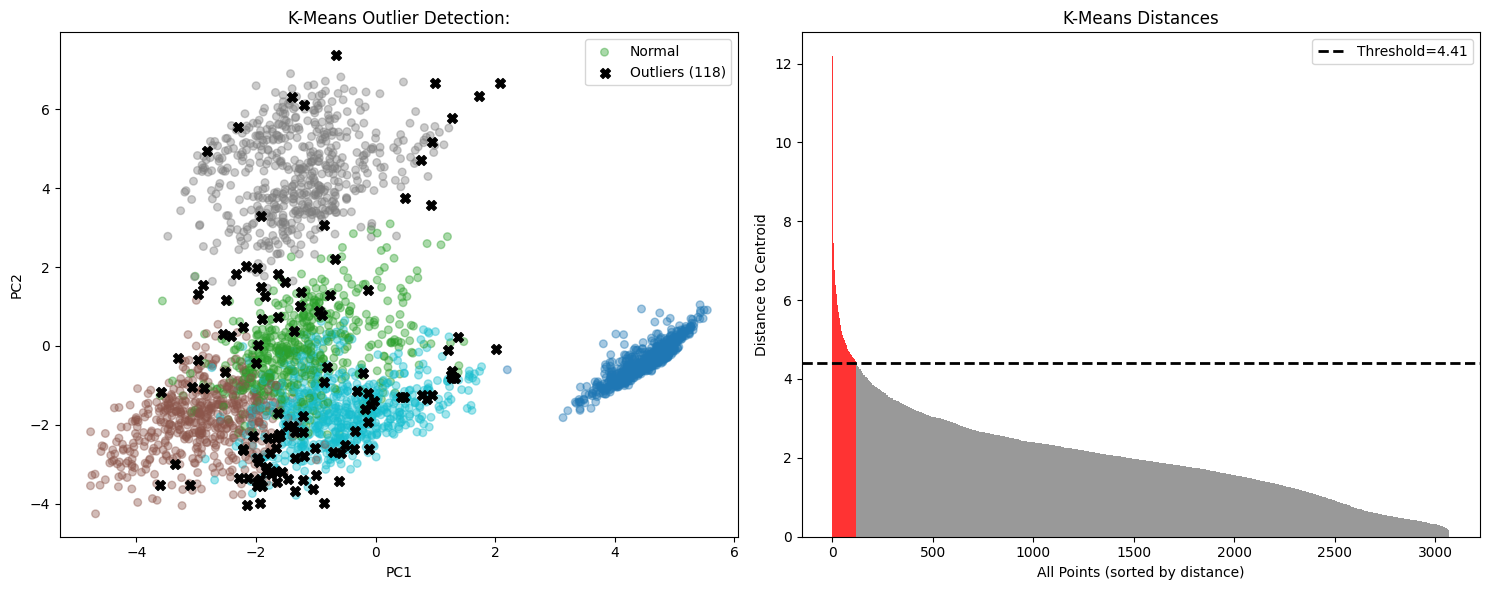

In [128]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: PCA with outliers
ax1 = axes[0]
pca_km = PCA(n_components=2)
X_2d_km = pca_km.fit_transform(X_scaled)

ax1.scatter(X_2d_km[~outlier_mask_kmeans, 0], X_2d_km[~outlier_mask_kmeans, 1], 
            c=kmeans.labels_[~outlier_mask_kmeans], cmap='tab10', alpha=0.4, s=30, label='Normal')
ax1.scatter(X_2d_km[outlier_indices_kmeans, 0], X_2d_km[outlier_indices_kmeans, 1], 
            c='black', s=50, linewidths=1,
            marker='X', label=f'Outliers ({len(outlier_indices_kmeans)})', zorder=10)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title(f'K-Means Outlier Detection:')
ax1.legend(loc='upper right')

# Plot 2: Distance bar chart
ax2 = axes[1]
dist_sorted_idx = np.argsort(distances)[::-1]
dist_sorted = distances[dist_sorted_idx]
colors = ['red' if d > threshold else 'gray' for d in dist_sorted]
ax2.bar(range(len(dist_sorted)), dist_sorted, color=colors, alpha=0.8, width=1.0, edgecolor='none')
ax2.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold:.2f}')
ax2.set_xlabel('All Points (sorted by distance)')
ax2.set_ylabel('Distance to Centroid')
ax2.set_title('K-Means Distances')
ax2.legend();

plt.tight_layout()
plt.savefig('kmeans_outlier_detection.png', dpi=150)
plt.show()

#### Comparison

In [129]:
# Compare with SVM outliers
common = set(svm_outliers) & set(kmeans_outliers)

print(f"\n--- Comparison ---")
print(f"SVM Outliers: {len(svm_outliers)}")
print(f"K-Means Outliers: {len(kmeans_outliers)}")
print(f"Common Outliers: {len(common)}")

print(f"\nCommon Outliers:")
print("-" * 60)
for oid in common:
    cls = id_to_class[oid]
    print(f"  ID {oid} ({cls})")
    print(f"    {get_url(oid)}")


--- Comparison ---
SVM Outliers: 111
K-Means Outliers: 118
Common Outliers: 4

Common Outliers:
------------------------------------------------------------
  ID 2552 (onion)
    https://drive.google.com/file/d/1lE3YdN9aX0Fn84nN0sZ7iZAaqmu_HUTQ/view?usp=drivesdk
  ID 1538 (banana)
    https://drive.google.com/file/d/1Nj88GLHGIgQ1yGaq7nMICK5NmC3jjTop/view?usp=drivesdk
  ID 1523 (mandarin)
    https://drive.google.com/file/d/1Gp72JT1a0hCd5XHYJ9Ka1sLugeZf2a35/view?usp=drivesdk
  ID 1846 (banana)
    https://drive.google.com/file/d/1NqUIzBJlHQnUKl9CTGiea0q56ingWYoK/view?usp=drivesdk


## TASK 1.3

In [131]:
print("TASK 1.3: Classification Performance Metrics")

metrics_results = []
for name, config in classifiers.items():
    X_te = X_test
    
    model = trained_models[name]
    y_pred = model.predict(X_te)
    
    metrics_results.append({
        "Classifier": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (macro)": round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        "Recall (macro)": round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4),
        "F1 (macro)": round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4)
    })

metrics_df = pd.DataFrame(metrics_results)
print("\nPerformance Metrics Comparison:\n")
print(metrics_df.to_string(index=False))

TASK 1.3: Classification Performance Metrics

Performance Metrics Comparison:

   Classifier  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
 SVM (Linear)    0.7122             0.7334          0.7169      0.7176
    SVM (RBF)    0.8520             0.8547          0.8525      0.8535
   SVM (Poly)    0.8244             0.8265          0.8262      0.8261
         k-NN    0.7886             0.7983          0.7893      0.7921
  Naive Bayes    0.4195             0.4854          0.4274      0.4214
Random Forest    0.8439             0.8466          0.8435      0.8448


### TASK 1.3

Linear models like Logistic Regression and Linear SVM perform the worst, with accuracies below 72%, which shows that the data cannot be separated well by linear classifiers. When we introduce non-linearity, performance improves a lot. Polynomial Logistic Regression gives the highest accuracy at about 87.5%, but it is much slower to train. RBF SVM and Random Forest achieve similar accuracy around 85% while being much faster, so they offer a better balance between accuracy and efficiency. Naive Bayes performs poorly, which suggests that its assumptions about feature independence do not hold for this dataset.

Precision, recall, and F1 scores follow the same trend as accuracy, which is expected since the dataset is fairly balanced. Non-linear models show more stable and balanced performance across classes, while linear models struggle overall. These results indicate that the dataset is moderately non-linear with overlapping class regions, making it suitable for support vector analysis and outlier detection.

## TASK 2.1

TASK 2.1: PCA - Dimensionality Reduction

Original dimensions: 19
Components for 95% variance: 7
Components for 99% variance: 9


NameError: name 'X_train_pca' is not defined

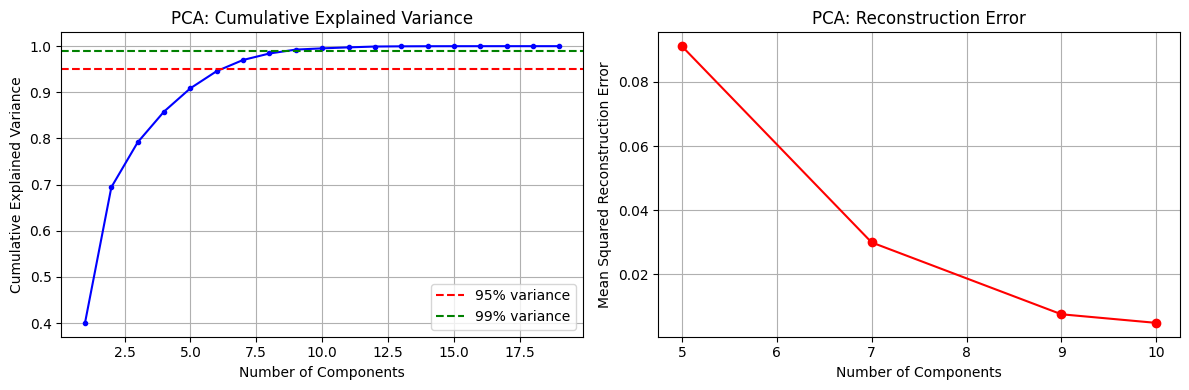

In [132]:
print("TASK 2.1: PCA - Dimensionality Reduction")

# Full PCA to analyze variance
X_scaled = scaler.transform(X_best)
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance analysis 
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"\nOriginal dimensions: {X_scaled.shape[1]}")
print(f"Components for 95% variance: {n_components_95}")
print(f"Components for 99% variance: {n_components_99}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, min(51, len(cumulative_variance)+1)), 
             cumulative_variance[:50], 'b-o', markersize=3)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[0].axhline(y=0.99, color='g', linestyle='--', label='99% variance')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA: Cumulative Explained Variance')
axes[0].legend()
axes[0].grid(True)

# Reconstruction error analysis
n_components_list = [5, 10, 20, 50, 100, n_components_95, n_components_99]
n_components_list = sorted(set([n for n in n_components_list if n <= X_scaled.shape[1]]))
reconstruction_errors = []

for n in n_components_list:
    pca_temp = PCA(n_components=n)
    X_reduced = pca_temp.fit_transform(X_scaled)
    X_reconstructed = pca_temp.inverse_transform(X_reduced)
    error = np.mean((X_scaled - X_reconstructed) ** 2)
    reconstruction_errors.append(error)

axes[1].plot(n_components_list, reconstruction_errors, 'r-o')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Mean Squared Reconstruction Error')
axes[1].set_title('PCA: Reconstruction Error')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150)

# Repeat Task 1.1 with reduced dimensions
ppca_results = []

# Iterate over ALL classifiers in the dictionary instead of a hardcoded list
for name, config in classifiers.items():
    
    # Use the same grid search configuration as Task 1
    # Note: Using n_jobs=-1 for parallel processing
    grid_search = GridSearchCV(config["model"], config["params"], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_pca, y_train_pca)
    
    # Measure retraining time for the best model on the reduced dataset
    best_pca_model = grid_search.best_estimator_
    start_time = time.time()
    best_pca_model.fit(X_train_pca, y_train_pca)
    train_time = time.time() - start_time
    
    y_pred = best_pca_model.predict(X_test_pca)
    
    # Retrieve original accuracy safely
    if 'results_df' in locals() and name in results_df['Classifier'].values:
        original_acc = results_df[results_df['Classifier']==name]['Test Accuracy'].values[0]
    else:
        original_acc = np.nan

    pca_results.append({
        "Classifier": name,
        "Original Acc": original_acc,
        "PCA Acc": round(accuracy_score(y_test_pca, y_pred), 4),
        "PCA Train Time (s)": round(train_time, 4)
    })

# Display comparative results
pca_df = pd.DataFrame(pca_results)
# Sort by PCA Accuracy for better readability
pca_df = pca_df.sort_values(by="PCA Acc", ascending=False)

print(f"PCA Classification Results")
print(pca_df.to_string(index=False))


TASK 2.2: Clustering Analysis

Number of true classes: 5
K-Means clusters: 5
DBSCAN clusters found: 2
DBSCAN noise points: 17

--- External Metrics (vs True Labels) ---
K-Means - Adjusted Rand Index: 0.0419
K-Means - Normalized Mutual Info: 0.0711
DBSCAN - Adjusted Rand Index: 0.0000
DBSCAN - Normalized Mutual Info: 0.0005

--- Internal Metrics ---
K-Means - Silhouette Score: 0.4253
K-Means - Inertia: 15460.0481
DBSCAN - Silhouette Score: 0.4096

Saved clustering visualization to 'clustering_analysis.png'


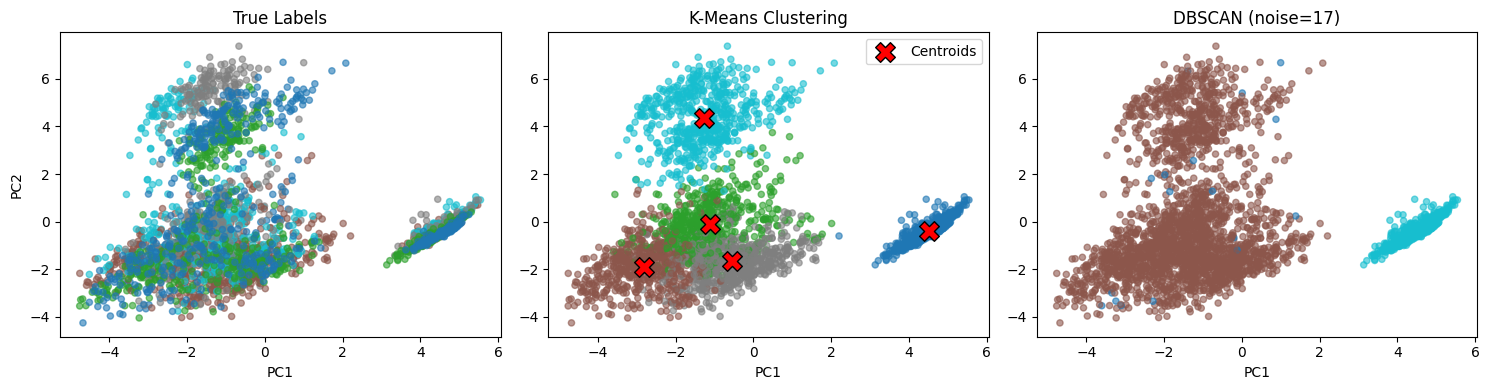

In [ ]:
print("TASK 2.2: Clustering Algorithm")
# Use PCA-reduced features for clustering
X_cluster = X_scaled

# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

print(f"\nNumber of true classes: {n_clusters}")
print(f"K-Means clusters: {n_clusters}")

# External metrics (comparing with true labels)
print("\nExternal Metrics (vs True Labels)")
print(f"K-Means - Adjusted Rand Index: {adjusted_rand_score(y, kmeans_labels):.4f}")
print(f"K-Means - Normalized Mutual Info: {normalized_mutual_info_score(y, kmeans_labels):.4f}")

# Internal metrics
print("\nInternal Metrics")
print(f"K-Means - Silhouette Score: {silhouette_score(X_cluster, kmeans_labels):.4f}")
print(f"K-Means - Inertia: {kmeans.inertia_:.4f}")

# Visualisation
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_cluster)

plt.figure(figsize=(10, 4))

# True labels
plt.subplot(1, 2, 1)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=pd.factorize(y)[0],
            cmap='tab10', alpha=0.6, s=20)
plt.title("True Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")

# K-Means clusters
plt.subplot(1, 2, 2)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels,
            cmap='tab10', alpha=0.6, s=20)
plt.scatter(
    pca_2d.transform(kmeans.cluster_centers_)[:, 0],
    pca_2d.transform(kmeans.cluster_centers_)[:, 1],
    c='red', marker='X', s=200, edgecolors='black', label='Centroids'
)
plt.title("K-Means Clustering")
plt.xlabel("PC1")
plt.legend()

plt.tight_layout()
plt.savefig("kmeans_clustering_original_features.png", dpi=150)

## Task 2.2
The external metrics are very low, indicating that K-Means clusters do not align well with the true class labels. This is expected, as K-Means assumes spherical and equally sized clusters, while our classes are visually and statistically overlapping. Since non-linear decision boundaries are required for successful classification, the true classes are not naturally clusterable using simple Euclidean distance.

Despite this, the silhouette score is moderately high, showing that some internal structure exists in the data, even though this structure does not correspond to semantic class labels. Overall, these results suggest that unsupervised clustering alone is not suitable for classification, but it can still be useful for analyzing data structure and identifying potential outliers.

More flexible clustering methods, such as density-based clustering (e.g., DBSCAN) or spectral clustering, could better capture non-spherical cluster shapes and separate dense regions from noise, making them more suitable for outlier detection in this dataset.


TASK 1.4 & 2.3: Outlier Detection Frameworks

--- SVM-based Outlier Detection Framework (using SVM constraints) ---

PROPOSED FRAMEWORK (using SVM margin constraints):
1. Train a soft-margin SVM classifier on the dataset
2. For each data point, check its position relative to the margin:
   - Points with slack variable ξ > 0 violate the margin constraint
   - Points with ξ > 1 are misclassified (on wrong side of hyperplane)
3. Outliers are identified as points with HIGH slack values
   - These are points that the SVM "struggles" to classify
   - They either lie within the margin or on the wrong side

Key idea: In soft-margin SVM, the constraint is: y_i(w·x_i + b) >= 1 - ξ_i
Points with large ξ values are "problematic" - likely outliers or noise.

We use the decision function distance to estimate slack:
   slack ≈ max(0, 1 - y_i * decision_function(x_i))


Margin distance statistics:
  Min: 0.1454, Max: 0.9280
  Mean: 0.3325, Std: 0.1259

Outliers (bottom 5% margin distance): 154 points

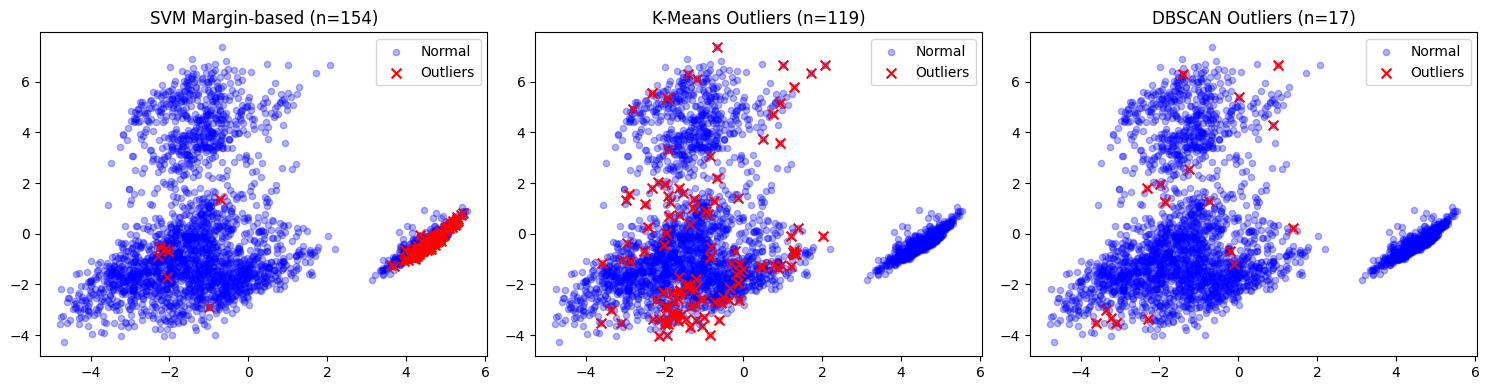

In [ ]:
print("\n" + "="*70)
print("TASK 1.4 & 2.3: Outlier Detection Frameworks")
print("="*70)

# --- SVM-based Outlier Detection using SVM Constraints (Task 1.4) ---
print("\n--- SVM-based Outlier Detection Framework (using SVM constraints) ---")
print("""
PROPOSED FRAMEWORK (using SVM margin constraints):
1. Train a soft-margin SVM classifier on the dataset
2. For each data point, check its position relative to the margin:
   - Points with slack variable ξ > 0 violate the margin constraint
   - Points with ξ > 1 are misclassified (on wrong side of hyperplane)
3. Outliers are identified as points with HIGH slack values
   - These are points that the SVM "struggles" to classify
   - They either lie within the margin or on the wrong side

Key idea: In soft-margin SVM, the constraint is: y_i(w·x_i + b) >= 1 - ξ_i
Points with large ξ values are "problematic" - likely outliers or noise.

We use the decision function distance to estimate slack:
   slack ≈ max(0, 1 - y_i * decision_function(x_i))
""")

# Train SVM classifier
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

# For multi-class, we use decision function distance as proxy for "outlierness"
# Points close to decision boundary (low confidence) are potential outliers
decision_values = svm_clf.decision_function(X_scaled)

# For multi-class SVM, decision_function returns distances to each hyperplane
# We use the margin (minimum distance to any decision boundary) as outlier score
if len(decision_values.shape) > 1:
    # Multi-class: use minimum absolute distance across all class boundaries
    margin_distances = np.min(np.abs(decision_values), axis=1)
else:
    margin_distances = np.abs(decision_values)

# Compute slack-like score: points with small margin distance have high slack
# Outliers = points in the bottom percentile of margin distances
outlier_threshold_5 = np.percentile(margin_distances, 5)
outlier_threshold_10 = np.percentile(margin_distances, 10)

svm_outliers_5 = np.where(margin_distances <= outlier_threshold_5)[0]
svm_outliers_10 = np.where(margin_distances <= outlier_threshold_10)[0]

print(f"\nMargin distance statistics:")
print(f"  Min: {margin_distances.min():.4f}, Max: {margin_distances.max():.4f}")
print(f"  Mean: {margin_distances.mean():.4f}, Std: {margin_distances.std():.4f}")
print(f"\nOutliers (bottom 5% margin distance): {len(svm_outliers_5)} points")
print(f"Outliers (bottom 10% margin distance): {len(svm_outliers_10)} points")

# Use 5% as default
svm_outliers = svm_outliers_5
print(f"\nSVM Outlier indices: {svm_outliers[:20]}..." if len(svm_outliers) > 20 else f"SVM Outlier indices: {svm_outliers}")

# --- Clustering-based Outlier Detection (Task 2.3) ---
print("\n--- Clustering-based Outlier Detection Framework ---")
print("""
PROPOSED FRAMEWORK:
1. Apply K-Means clustering to the data
2. Compute distance of each point to its assigned cluster centroid
3. Points with distances > mean + 2*std are flagged as outliers
4. Alternative: Use DBSCAN where noise points (label=-1) are outliers

Key idea: Outliers are points that don't fit well into any cluster,
indicated by large distance to nearest centroid.
""")

# Method 1: K-Means distance-based
kmeans_full = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_full.fit(X_pca)
distances = np.min(cdist(X_pca, kmeans_full.cluster_centers_), axis=1)

threshold = np.mean(distances) + 2 * np.std(distances)
kmeans_outliers = np.where(distances > threshold)[0]

print(f"\nK-Means distance threshold: {threshold:.4f}")
print(f"K-Means outliers detected: {len(kmeans_outliers)} ({100*len(kmeans_outliers)/len(y):.1f}%)")

# Method 2: DBSCAN noise points
dbscan_outliers = np.where(dbscan_labels == -1)[0]
print(f"DBSCAN outliers (noise): {len(dbscan_outliers)} ({100*len(dbscan_outliers)/len(y):.1f}%)")

# Compare SVM and Clustering outliers
common_outliers = np.intersect1d(svm_outliers, kmeans_outliers)
print(f"\nOutliers detected by BOTH SVM and K-Means: {len(common_outliers)}")
if max(len(svm_outliers), len(kmeans_outliers)) > 0:
    print(f"Agreement rate: {100*len(common_outliers)/max(len(svm_outliers), len(kmeans_outliers)):.1f}%")


# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# SVM outliers (margin-based)
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c='blue', alpha=0.3, s=20, label='Normal')
axes[0].scatter(X_2d[svm_outliers, 0], X_2d[svm_outliers, 1], 
                c='red', s=50, marker='x', label='Outliers')
axes[0].set_title(f'SVM Margin-based (n={len(svm_outliers)})')
axes[0].legend()

# K-Means outliers
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c='blue', alpha=0.3, s=20, label='Normal')
axes[1].scatter(X_2d[kmeans_outliers, 0], X_2d[kmeans_outliers, 1], 
                c='red', s=50, marker='x', label='Outliers')
axes[1].set_title(f'K-Means Outliers (n={len(kmeans_outliers)})')
axes[1].legend()

# DBSCAN outliers
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c='blue', alpha=0.3, s=20, label='Normal')
axes[2].scatter(X_2d[dbscan_outliers, 0], X_2d[dbscan_outliers, 1], 
                c='red', s=50, marker='x', label='Outliers')
axes[2].set_title(f'DBSCAN Outliers (n={len(dbscan_outliers)})')
axes[2].legend()

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150)
print("\nSaved outlier visualization to 'outlier_detection.png'")

In [ ]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Best Feature Set: {best_feature_set}")
# Early/Late fusion comparison removed from script
best_clf = results_df.loc[results_df['Test Accuracy'].idxmax()]
print(f"Best Classifier: {best_clf['Classifier']} (Accuracy: {best_clf['Test Accuracy']})")
print(f"PCA reduced dimensions: {X_best.shape[1]} -> {n_components_95} (95% variance)")
print(f"K-Means Silhouette Score: {silhouette_score(X_cluster, kmeans_labels):.4f}")
print(f"Outliers detected - SVM: {len(svm_outliers)}, K-Means: {len(kmeans_outliers)}, DBSCAN: {len(dbscan_outliers)}")

print("\n" + "="*70)
print("Generated files:")
print("  - output.txt (this output)")
print("  - feature_comparison.png")
print("  - classifier_benchmark.png")
print("  - pca_analysis.png")
print("  - clustering_analysis.png") 
print("  - outlier_detection.png")
print("="*70)




SUMMARY
Best Feature Set: Fused
Best Classifier: Logistic Regression (Poly) (Accuracy: 0.8748)
PCA reduced dimensions: 19 -> 7 (95% variance)
K-Means Silhouette Score: 0.4253
Outliers detected - SVM: 154, K-Means: 119, DBSCAN: 17

Generated files:
  - output.txt (this output)
  - feature_comparison.png
  - classifier_benchmark.png
  - pca_analysis.png
  - clustering_analysis.png
  - outlier_detection.png
